In [ ]:

# Download DASS dataset directly in Colab
!wget https://openpsychometrics.org/_rawdata/DASS_data_21.02.19.zip
!unzip DASS_data_21.02.19.zip

import pandas as pd
df = pd.read_csv('DASS_data_21.02.19/data.csv', sep='\t')
print(f"Shape: {df.shape}")
print(df.head())
print(df.columns.tolist())



--2026-05-01 16:27:38--  https://openpsychometrics.org/_rawdata/DASS_data_21.02.19.zip
Resolving openpsychometrics.org (openpsychometrics.org)... 45.79.49.240
Connecting to openpsychometrics.org (openpsychometrics.org)|45.79.49.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7129804 (6.8M) [application/zip]
Saving to: ‘DASS_data_21.02.19.zip’

DASS_data_21.02.19. 100%[===================>]   6.80M  3.81MB/s    in 1.8s    

2026-05-01 16:27:42 (3.81 MB/s) - ‘DASS_data_21.02.19.zip’ saved [7129804/7129804]

Archive:  DASS_data_21.02.19.zip
   creating: DASS_data_21.02.19/
  inflating: DASS_data_21.02.19/codebook.txt  
  inflating: DASS_data_21.02.19/data.csv  
  inflating: DASS_data_21.02.19/demo1.png  
Shape: (39775, 172)
   Q1A  Q1I   Q1E  Q2A  Q2I   Q2E  Q3A  Q3I   Q3E  Q4A  ...  screensize  \
0    4   28  3890    4   25  2122    2   16  1944    4  ...           1   
1    4    2  8118    1   36  2890    2   35  4777    3  ...           2   
2    3    7  5

# CELL 1 — Install & Import


In [ ]:
!pip install imbalanced-learn shap lime lightgbm xgboost --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, matthews_corrcoef, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import lime
import lime.lime_tabular
import joblib, zipfile, os

print("✅ All libraries imported!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 20.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All libraries imported!


# CELL 2 — Load & Parse DASS Dataset


In [ ]:
# Load raw data
df_raw = pd.read_csv('DASS_data_21.02.19/data.csv', sep='\t', low_memory=False)
print(f"Raw shape: {df_raw.shape}")

# ── DASS-42 subscale item mapping ─────────────────────────────────────────────
# Each Q has suffix A (answer), I (position), E (elapsed time)
# We only need the 'A' (answer) columns — the actual responses

# Depression items (Q*A): 3,5,10,13,16,17,21,24,26,31,34,37,38,42
# Anxiety items:          1,2,4,6,7,8,12,15,18,19,22,28,33,41 (scaled Q*)
# Actually DASS-42 official subscales:
depression_items = [3,5,10,13,16,17,21,24,26,31,34,37,38,42]
anxiety_items    = [2,4,7,9,15,19,20,23,25,28,30,36,40,41]
stress_items     = [1,6,8,11,12,14,18,22,27,29,32,33,35,39]

dep_cols   = [f"Q{i}A" for i in depression_items]
anx_cols   = [f"Q{i}A" for i in anxiety_items]
stress_cols= [f"Q{i}A" for i in stress_items]

# All DASS answer columns
all_dass_cols = [f"Q{i}A" for i in range(1, 43)]

# Demographic features to keep
demo_cols = ['age', 'gender', 'education', 'urban', 'engnat',
             'hand', 'religion', 'orientation', 'race',
             'married', 'familysize']

# ── Compute subscale scores ───────────────────────────────────────────────────
# DASS scoring: sum of item responses (1-4 scale → subtract 1 → 0-3 scale)
# Then multiply by 2 for DASS-42 (to match DASS-21 norms)

df = df_raw[all_dass_cols + demo_cols].copy()

# Convert answer columns to numeric, coerce errors
for col in all_dass_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check valid range (should be 1-4)
print(f"\nResponse range check (Q1A): {df['Q1A'].min()} to {df['Q1A'].max()}")

# Recode: valid responses are 1,2,3,4 → remap to 0,1,2,3
for col in all_dass_cols:
    df[col] = df[col] - 1   # now 0–3

# Compute subscale scores
df['Depression_Score'] = df[dep_cols].sum(axis=1)
df['Anxiety_Score']    = df[anx_cols].sum(axis=1)
df['Stress_Score']     = df[stress_cols].sum(axis=1)

print(f"\nDepression Score range: {df['Depression_Score'].min():.0f} – {df['Depression_Score'].max():.0f}")
print(f"Anxiety Score range   : {df['Anxiety_Score'].min():.0f} – {df['Anxiety_Score'].max():.0f}")
print(f"Stress Score range    : {df['Stress_Score'].min():.0f} – {df['Stress_Score'].max():.0f}")

# ── Label encoding: Depression severity (DASS-42 cutoffs) ────────────────────
# Depression: 0–9=Normal, 10–13=Mild, 14–20=Moderate, 21–27=Severe, 28+=Ext.Severe
# (multiply raw DASS-42 score by 2 to compare with published cutoffs)
def encode_depression(score):
    s = score * 2   # scale to DASS-21 equivalent
    if   s <= 9:  return 0   # Normal
    elif s <= 13: return 1   # Mild
    elif s <= 20: return 2   # Moderate
    elif s <= 27: return 3   # Severe
    else:         return 4   # Extremely Severe

def encode_anxiety(score):
    s = score * 2
    if   s <= 7:  return 0
    elif s <= 9:  return 1
    elif s <= 14: return 2
    elif s <= 19: return 3
    else:         return 4

def encode_stress(score):
    s = score * 2
    if   s <= 14: return 0
    elif s <= 18: return 1
    elif s <= 25: return 2
    elif s <= 33: return 3
    else:         return 4

df['Depression_Label'] = df['Depression_Score'].apply(encode_depression)
df['Anxiety_Label']    = df['Anxiety_Score'].apply(encode_anxiety)
df['Stress_Label']     = df['Stress_Score'].apply(encode_stress)

severity_labels = {0: "Normal", 1: "Mild", 2: "Moderate",
                   3: "Severe", 4: "Extremely Severe"}

print("\n✅ Labels created:")
print(f"Depression: {dict(df['Depression_Label'].value_counts().sort_index())}")
print(f"Anxiety   : {dict(df['Anxiety_Label'].value_counts().sort_index())}")
print(f"Stress    : {dict(df['Stress_Label'].value_counts().sort_index())}")


Raw shape: (39775, 172)

Response range check (Q1A): 1 to 4

Depression Score range: 0 – 42
Anxiety Score range   : 0 – 42
Stress Score range    : 0 – 42

✅ Labels created:
Depression: {0: np.int64(4318), 1: np.int64(1755), 2: np.int64(3698), 3: np.int64(2871), 4: np.int64(27133)}
Anxiety   : {0: np.int64(4279), 1: np.int64(1323), 2: np.int64(4126), 3: np.int64(2764), 4: np.int64(27283)}
Stress    : {0: np.int64(4439), 1: np.int64(1813), 2: np.int64(3231), 3: np.int64(4756), 4: np.int64(25536)}


# CELL 3 — Clean & Prepare Final Dataset


In [ ]:
# ── Keep DASS items + demographics + scores + labels ─────────────────────────
keep_cols = (all_dass_cols + demo_cols +
             ['Depression_Score', 'Anxiety_Score', 'Stress_Score',
              'Depression_Label', 'Anxiety_Label', 'Stress_Label'])

df_model = df[keep_cols].copy()

# Convert demographics to numeric
for col in demo_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Drop rows with missing values
before = len(df_model)
df_model.dropna(inplace=True)
after  = len(df_model)
df_model.reset_index(drop=True, inplace=True)

print(f"Rows before cleaning : {before}")
print(f"Rows after  cleaning : {after}")
print(f"Dropped              : {before - after}")
print(f"\n✅ Final dataset shape: {df_model.shape}")
print(f"\nColumns available: {list(df_model.columns)}")

print(f"\nClass distribution — Depression:")
for k, v in df_model['Depression_Label'].value_counts().sort_index().items():
    print(f"  {severity_labels[k]:20s}: {v:5d} ({v/len(df_model)*100:.1f}%)")


Rows before cleaning : 39775
Rows after  cleaning : 39775
Dropped              : 0

✅ Final dataset shape: (39775, 59)

Columns available: ['Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A', 'Q7A', 'Q8A', 'Q9A', 'Q10A', 'Q11A', 'Q12A', 'Q13A', 'Q14A', 'Q15A', 'Q16A', 'Q17A', 'Q18A', 'Q19A', 'Q20A', 'Q21A', 'Q22A', 'Q23A', 'Q24A', 'Q25A', 'Q26A', 'Q27A', 'Q28A', 'Q29A', 'Q30A', 'Q31A', 'Q32A', 'Q33A', 'Q34A', 'Q35A', 'Q36A', 'Q37A', 'Q38A', 'Q39A', 'Q40A', 'Q41A', 'Q42A', 'age', 'gender', 'education', 'urban', 'engnat', 'hand', 'religion', 'orientation', 'race', 'married', 'familysize', 'Depression_Score', 'Anxiety_Score', 'Stress_Score', 'Depression_Label', 'Anxiety_Label', 'Stress_Label']

Class distribution — Depression:
  Normal              :  4318 (10.9%)
  Mild                :  1755 (4.4%)
  Moderate            :  3698 (9.3%)
  Severe              :  2871 (7.2%)
  Extremely Severe    : 27133 (68.2%)


# CELL 4 — EDA


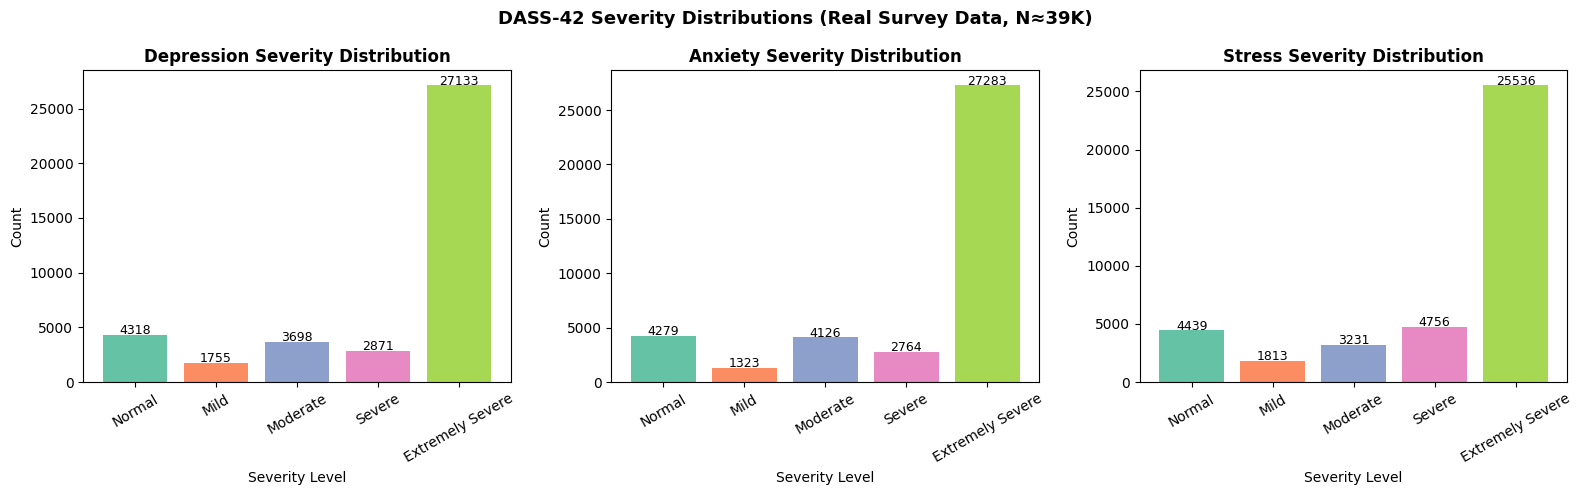

✅ Saved: dass_class_distribution.png


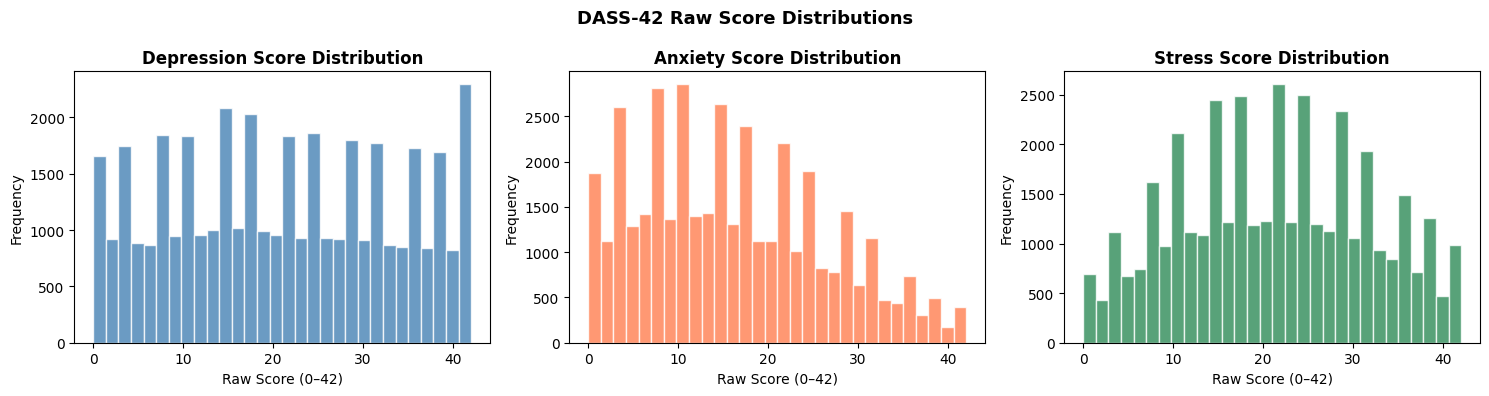

✅ Saved: dass_score_distributions.png


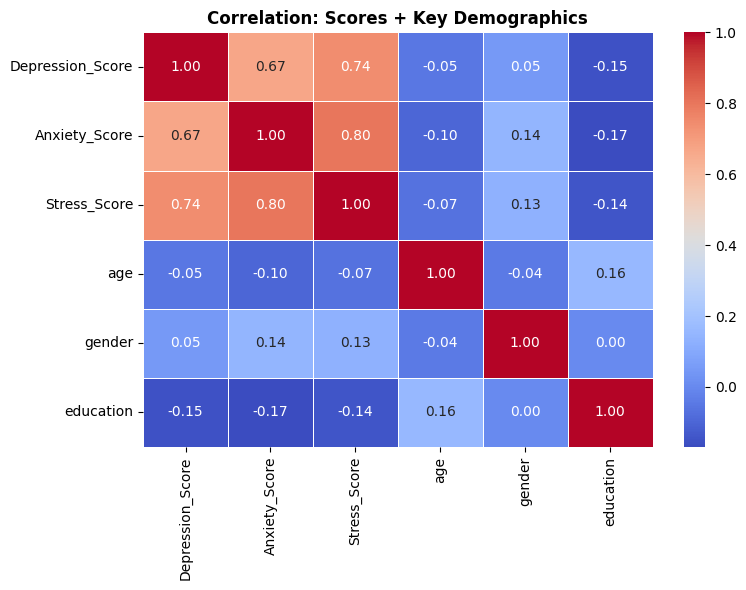

✅ Saved: dass_correlation.png


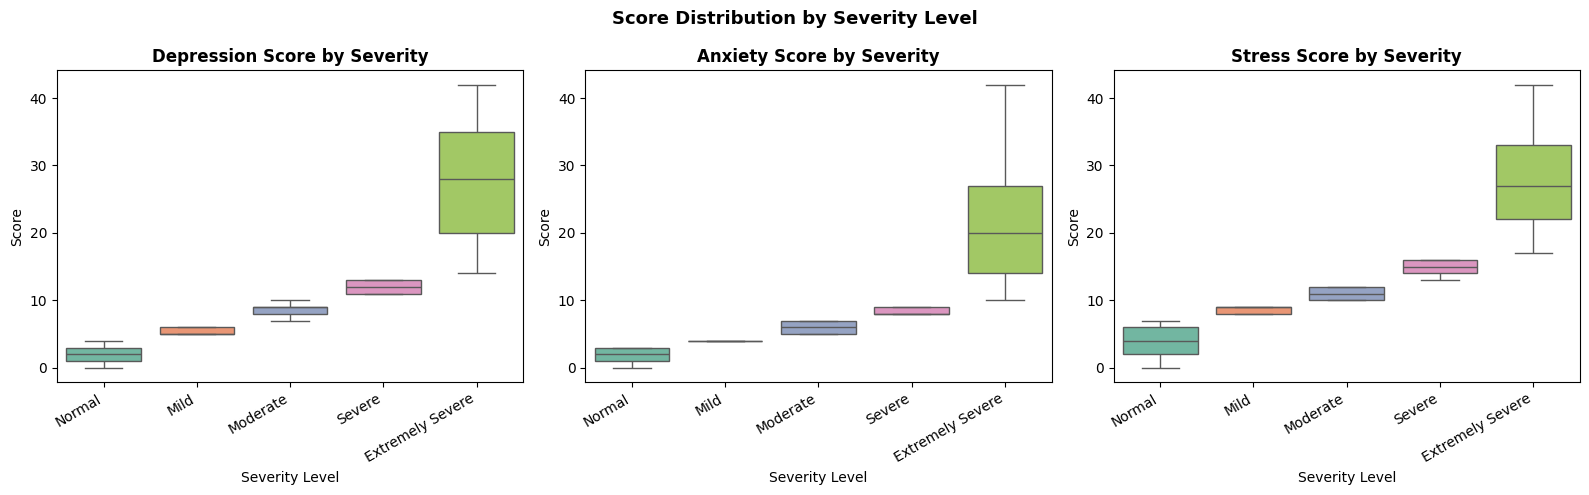

✅ Saved: dass_score_by_severity.png


In [ ]:
# ── Class distribution for all 3 conditions ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label_col, title) in zip(axes, [
    ('Depression_Label', 'Depression'),
    ('Anxiety_Label',    'Anxiety'),
    ('Stress_Label',     'Stress')
]):
    counts = df_model[label_col].value_counts().sort_index()
    bars = ax.bar([severity_labels[i] for i in counts.index],
                  counts.values, color=plt.cm.Set2.colors[:5])
    ax.set_title(f'{title} Severity Distribution', fontweight='bold')
    ax.set_xlabel('Severity Level')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 50, str(val),
                ha='center', fontsize=9)

plt.suptitle('DASS-42 Severity Distributions (Real Survey Data, N≈39K)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dass_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: dass_class_distribution.png")

# ── Score distributions ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (score, title, color) in zip(axes, [
    ('Depression_Score', 'Depression', 'steelblue'),
    ('Anxiety_Score',    'Anxiety',    'coral'),
    ('Stress_Score',     'Stress',     'seagreen')
]):
    ax.hist(df_model[score], bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(f'{title} Score Distribution', fontweight='bold')
    ax.set_xlabel('Raw Score (0–42)')
    ax.set_ylabel('Frequency')

plt.suptitle('DASS-42 Raw Score Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dass_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: dass_score_distributions.png")

# ── Correlation heatmap ───────────────────────────────────────────────────────
corr_cols = ['Depression_Score', 'Anxiety_Score', 'Stress_Score',
             'age', 'gender', 'education']
corr_cols = [c for c in corr_cols if c in df_model.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(df_model[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation: Scores + Key Demographics', fontweight='bold')
plt.tight_layout()
plt.savefig('dass_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: dass_correlation.png")

# ── Score vs severity boxplot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (score, label_col, title) in zip(axes, [
    ('Depression_Score', 'Depression_Label', 'Depression'),
    ('Anxiety_Score',    'Anxiety_Label',    'Anxiety'),
    ('Stress_Score',     'Stress_Label',     'Stress')
]):
    sns.boxplot(data=df_model, x=label_col, y=score,
                palette='Set2', ax=ax)
    ax.set_xticklabels([severity_labels[i]
                        for i in sorted(df_model[label_col].unique())],
                       rotation=30, ha='right')
    ax.set_title(f'{title} Score by Severity', fontweight='bold')
    ax.set_xlabel('Severity Level')
    ax.set_ylabel('Score')

plt.suptitle('Score Distribution by Severity Level', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dass_score_by_severity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: dass_score_by_severity.png")


# CELL 5 FIX — Preprocessing


Total features       : 53
  DASS item responses: 42
  Demographic cols   : 11
  Demographic list   : ['age', 'gender', 'education', 'urban', 'engnat', 'hand', 'religion', 'orientation', 'race', 'married', 'familysize']

✅ Z-score applied to: ['age', 'familysize']

Top 20 features by ANOVA F-score:
Feature      F-Score  P-Value
   Q13A 10245.575169      0.0
   Q34A  9380.741940      0.0
   Q17A  9357.047997      0.0
   Q10A  8154.574568      0.0
   Q38A  7849.981236      0.0
   Q16A  7829.333379      0.0
   Q21A  7778.163681      0.0
   Q26A  7762.004892      0.0
   Q37A  6823.052628      0.0
   Q24A  6560.412309      0.0
    Q5A  6519.325612      0.0
   Q31A  6067.866612      0.0
    Q3A  5939.397465      0.0
   Q42A  4914.122367      0.0
   Q11A  4268.978698      0.0
    Q1A  3516.226026      0.0
   Q27A  3327.930810      0.0
   Q29A  3301.015542      0.0
    Q8A  3098.814278      0.0
   Q36A  3049.996799      0.0


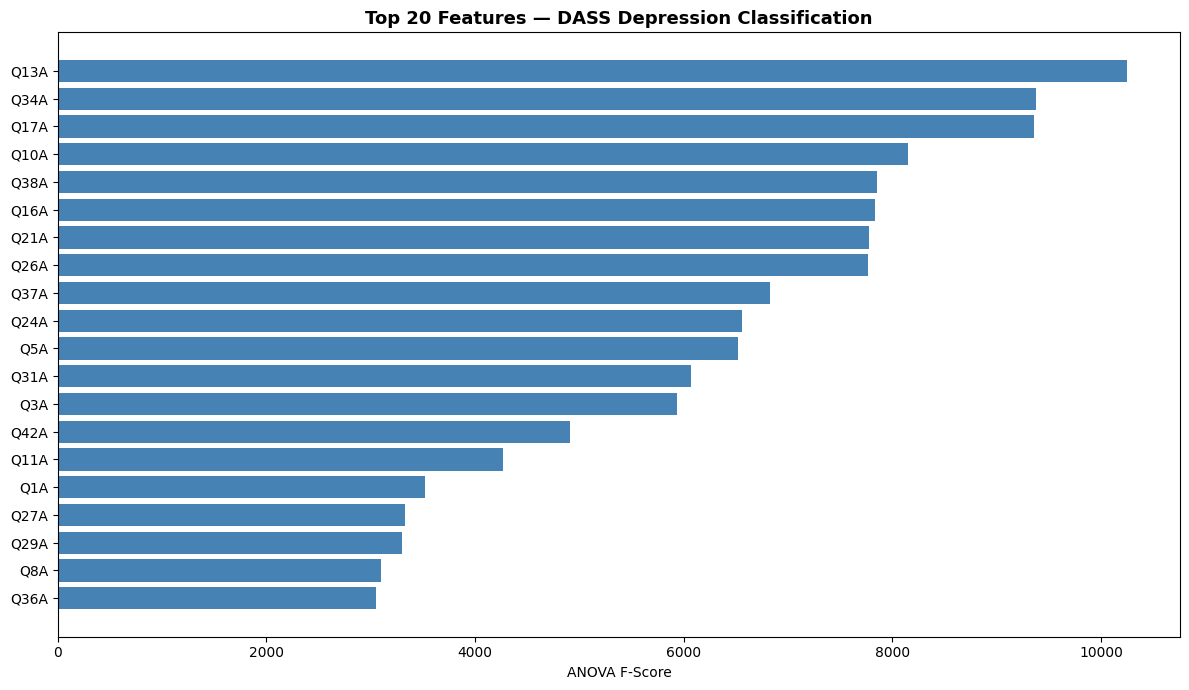

✅ Saved: dass_anova_features.png

✅ Significant features (p<0.05): 53
  ['Q13A', 'Q34A', 'Q17A', 'Q10A', 'Q38A', 'Q16A', 'Q21A', 'Q26A', 'Q37A', 'Q24A', 'Q5A', 'Q31A', 'Q3A', 'Q42A', 'Q11A', 'Q1A', 'Q27A', 'Q29A', 'Q8A', 'Q36A', 'Q22A', 'Q39A', 'Q20A', 'Q33A', 'Q30A', 'Q40A', 'Q12A', 'Q9A', 'Q28A', 'Q6A', 'Q32A', 'Q35A', 'Q18A', 'Q15A', 'Q4A', 'Q7A', 'Q25A', 'Q14A', 'Q41A', 'Q23A', 'Q2A', 'Q19A', 'education', 'married', 'orientation', 'age', 'religion', 'gender', 'familysize', 'race', 'engnat', 'urban', 'hand']

Train (raw): 31820 | Test: 7955
Test class dist: {0: np.int64(864), 1: np.int64(351), 2: np.int64(740), 3: np.int64(574), 4: np.int64(5426)}

Applying SMOTETomek on training set only...

Train before: {0: np.int64(3454), 1: np.int64(1404), 2: np.int64(2958), 3: np.int64(2297), 4: np.int64(21707)}
Train after : {0: np.int64(21707), 1: np.int64(21707), 2: np.int64(21707), 3: np.int64(21707), 4: np.int64(21707)}

✅ Final train : (108535, 53)
   Final test  : (7955, 53)  ← untouche

In [ ]:
# ── Features: DASS 42 items + demographics ────────────────────────────────────
# EXCLUDE raw scores and all label columns (they encode the target → leakage)
TARGET  = 'Depression_Label'
EXCLUDE = ['Depression_Label', 'Anxiety_Label',   'Stress_Label',
           'Depression_Score', 'Anxiety_Score',    'Stress_Score']

feature_cols = [c for c in df_model.columns if c not in EXCLUDE]
print(f"Total features       : {len(feature_cols)}")
print(f"  DASS item responses: {len([c for c in feature_cols if c.startswith('Q')])}")
print(f"  Demographic cols   : {len([c for c in feature_cols if not c.startswith('Q')])}")
print(f"  Demographic list   : {[c for c in feature_cols if not c.startswith('Q')]}")

X = df_model[feature_cols].copy()
y = df_model[TARGET].copy()

# ── Z-score normalisation on continuous demographics ──────────────────────────
continuous_demo = [c for c in ['age', 'familysize'] if c in X.columns]
scaler = StandardScaler()
X[continuous_demo] = scaler.fit_transform(X[continuous_demo])
print(f"\n✅ Z-score applied to: {continuous_demo}")

# ── ANOVA F-test ──────────────────────────────────────────────────────────────
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

f_scores_df = pd.DataFrame({
    'Feature': feature_cols,
    'F-Score': selector.scores_,
    'P-Value': selector.pvalues_
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print(f"\nTop 20 features by ANOVA F-score:")
print(f_scores_df.head(20).to_string(index=False))

plt.figure(figsize=(12, 7))
top20 = f_scores_df.head(20)
plt.barh(top20['Feature'][::-1], top20['F-Score'][::-1], color='steelblue')
plt.xlabel('ANOVA F-Score')
plt.title('Top 20 Features — DASS Depression Classification',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dass_anova_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: dass_anova_features.png")

# ── Select statistically significant features (p < 0.05) ─────────────────────
significant   = f_scores_df[f_scores_df['P-Value'] < 0.05]
top_features  = significant['Feature'].tolist()
print(f"\n✅ Significant features (p<0.05): {len(top_features)}")
print(f"  {top_features}")

X_selected = X[top_features].copy()

# ── Train / test split (80/20 stratified) ─────────────────────────────────────
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_selected, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain (raw): {X_train_raw.shape[0]} | Test: {X_test.shape[0]}")
print(f"Test class dist: {dict(pd.Series(y_test).value_counts().sort_index())}")

# ── SMOTETomek on training set ONLY ──────────────────────────────────────────
print("\nApplying SMOTETomek on training set only...")
smt = SMOTETomek(random_state=42)
X_train, y_train = smt.fit_resample(X_train_raw, y_train_raw)

print(f"\nTrain before: {dict(pd.Series(y_train_raw).value_counts().sort_index())}")
print(f"Train after : {dict(pd.Series(y_train).value_counts().sort_index())}")
print(f"\n✅ Final train : {X_train.shape}")
print(f"   Final test  : {X_test.shape}  ← untouched, never balanced")

# ── Zero-variance sanity check ────────────────────────────────────────────────
print("\n🔍 Zero-variance check per class on original training data...")
zero_std_count = 0
for feat in top_features[:10]:   # check top 10 only for speed
    stds = df_model.groupby(TARGET)[feat].std()
    if (stds == 0).any():
        zero_std_count += 1
        print(f"  ⚠️  '{feat}' has std=0 in some class!")
if zero_std_count == 0:
    print("  ✅ No zero-variance features — DASS data is genuine survey data!")


# Cell 6 - Baseline Using GPU


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import SMOTE
import time
import warnings
warnings.filterwarnings("ignore")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Reduce feature set to top 20 DASS items only ─────────────────────────────
TOP_K        = 20
top_features = f_scores_df.head(TOP_K)['Feature'].tolist()
print(f"Using top {TOP_K} features: {top_features}")

X_train_raw_fast = X_train_raw[top_features].copy()
X_test_fast      = X_test[top_features].copy()
X_train_fast     = X_train[top_features].copy()

# ── GPU Enabled Baseline Models (SVM REMOVED) ────────────────────────────────
baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=500,
        random_state=42,
        class_weight='balanced',
        solver='saga',
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    # GPU XGBoost
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        eval_metric='mlogloss',
        random_state=42,
        tree_method="hist",
        device="cuda",
        n_jobs=1
    ),

    # GPU LightGBM
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        verbose=-1,
        device='gpu',
        n_jobs=1
    ),

    # MLP (CPU)
    "MLP (standalone)": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=100,
        random_state=42,
        early_stopping=True
    )
}

results_cv    = []
fitted_models = {}

print("\n" + "=" * 65)
print("  Baselines — 5-Fold CV | GPU Enabled | DASS Depression (NO SVM)")
print("=" * 65)

for name, model in baseline_models.items():

    pipe = ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", model)
    ])

    print(f"\nCV: {name}...")
    t0 = time.time()

    jobs_used = 1 if name in ["XGBoost", "LightGBM"] else -1

    cv_res = cross_validate(
        pipe,
        X_train_raw_fast,
        y_train_raw,
        cv=cv_strategy,
        scoring=["accuracy", "f1_macro"],
        n_jobs=jobs_used
    )

    elapsed = time.time() - t0

    acc_mean = cv_res["test_accuracy"].mean()
    acc_std  = cv_res["test_accuracy"].std()
    f1_mean  = cv_res["test_f1_macro"].mean()
    f1_std   = cv_res["test_f1_macro"].std()

    # ── Train Full Model ──────────────────────────────────────────────────────
    model.fit(X_train_fast, y_train)
    fitted_models[name] = model

    y_pred = model.predict(X_test_fast)

    acc_t = accuracy_score(y_test, y_pred)
    f1_t  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    mcc_t = matthews_corrcoef(y_test, y_pred)

    try:
        proba = model.predict_proba(X_test_fast)
        auc_t = roc_auc_score(
            y_test,
            proba,
            multi_class='ovr',
            average='macro'
        )
    except:
        auc_t = float("nan")

    print(f"  Time: {elapsed:.1f}s")
    print(f"  CV  : Acc={acc_mean*100:.2f}%±{acc_std*100:.2f} "
          f"F1={f1_mean*100:.2f}%±{f1_std*100:.2f}")
    print(f"  Test: Acc={acc_t*100:.2f}% "
          f"F1={f1_t*100:.2f}% "
          f"MCC={mcc_t:.4f} "
          f"AUC={auc_t:.4f}")

    results_cv.append({
        "Model"         : name,
        "CV Acc (%)"    : f"{acc_mean*100:.2f} ± {acc_std*100:.2f}",
        "CV F1 (%)"     : f"{f1_mean*100:.2f} ± {f1_std*100:.2f}",
        "Test Accuracy" : round(acc_t * 100, 2),
        "Test Macro F1" : round(f1_t  * 100, 2),
        "MCC"           : round(mcc_t, 4),
        "AUC-ROC"       : round(auc_t, 4)
    })

# ── Final Table ───────────────────────────────────────────────────────────────
baseline_df = pd.DataFrame(results_cv).sort_values(
    "Test Macro F1",
    ascending=False
).reset_index(drop=True)

print("\n📊 Baseline Results:")
display(baseline_df)

baseline_df.to_csv("baseline_results_dass.csv", index=False)


Using top 20 features: ['Q13A', 'Q34A', 'Q17A', 'Q10A', 'Q38A', 'Q16A', 'Q21A', 'Q26A', 'Q37A', 'Q24A', 'Q5A', 'Q31A', 'Q3A', 'Q42A', 'Q11A', 'Q1A', 'Q27A', 'Q29A', 'Q8A', 'Q36A']

  Baselines — 5-Fold CV | GPU Enabled | DASS Depression (NO SVM)

CV: Logistic Regression...
  Time: 185.1s
  CV  : Acc=89.85%±0.56 F1=71.59%±1.39
  Test: Acc=83.51% F1=53.24% MCC=0.6818 AUC=0.9687

CV: Decision Tree...
  Time: 3.5s
  CV  : Acc=81.35%±0.55 F1=61.66%±0.62
  Test: Acc=78.30% F1=53.00% MCC=0.5935 AUC=0.9261

CV: Random Forest...
  Time: 30.8s
  CV  : Acc=88.88%±0.44 F1=70.29%±0.84
  Test: Acc=84.15% F1=57.71% MCC=0.6917 AUC=0.9558

CV: XGBoost...
  Time: 6.4s
  CV  : Acc=87.74%±0.58 F1=70.10%±0.90
  Test: Acc=83.39% F1=56.53% MCC=0.6822 AUC=0.9662

CV: LightGBM...
  Time: 33.3s
  CV  : Acc=88.59%±0.47 F1=70.04%±0.96
  Test: Acc=83.19% F1=54.75% MCC=0.6753 AUC=0.9646

CV: MLP (standalone)...
  Time: 252.3s
  CV  : Acc=89.08%±0.23 F1=69.06%±0.74
  Test: Acc=85.02% F1=58.41% MCC=0.7095 AUC=0.9727


,Model,CV Acc (%),CV F1 (%),Test Accuracy,Test Macro F1,MCC,AUC-ROC
0,MLP (standalone),89.08 ± 0.23,69.06 ± 0.74,85.02,58.41,0.7095,0.9727
1,Random Forest,88.88 ± 0.44,70.29 ± 0.84,84.15,57.71,0.6917,0.9558
2,XGBoost,87.74 ± 0.58,70.10 ± 0.90,83.39,56.53,0.6822,0.9662
3,LightGBM,88.59 ± 0.47,70.04 ± 0.96,83.19,54.75,0.6753,0.9646
4,Logistic Regression,89.85 ± 0.56,71.59 ± 1.39,83.51,53.24,0.6818,0.9687
5,Decision Tree,81.35 ± 0.55,61.66 ± 0.62,78.30,53.00,0.5935,0.9261


# CELL 7 GPU-OPTIMIZED — DepressNet with T4 GPU


In [ ]:
import time

# ── Verify GPU availability ───────────────────────────────────────────────────
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout[:500])

import torch
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name       : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Install GPU-enabled libraries ─────────────────────────────────────────────
# XGBoost and LightGBM support GPU natively
# PyTorch MLP will replace sklearn MLP for GPU acceleration
!pip install torch --quiet

print("\n✅ GPU environment ready!")


Fri May  1 16:43:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       
CUDA available : True
GPU name       : Tesla T4
GPU memory     : 15.6 GB

✅ GPU environment ready!


# CELL 7B — DepressNet with GPU Base Learners + PyTorch Meta-Learner


Using device: cuda
✅ GPU base learners configured.
✅ PyTorch MLP defined.

  Phase 1: Out-Of-Fold base learner predictions

  Base learner: XGBoost
    Fold 1/5 | Val Acc=86.29% | Time=2.9s
    Fold 2/5 | Val Acc=86.32% | Time=2.5s
    Fold 3/5 | Val Acc=86.31% | Time=2.5s
    Fold 4/5 | Val Acc=86.14% | Time=2.7s
    Fold 5/5 | Val Acc=86.43% | Time=3.0s
  ✅ XGBoost OOF done.

  Base learner: RF
    Fold 1/5 | Val Acc=85.14% | Time=11.3s
    Fold 2/5 | Val Acc=85.65% | Time=11.8s
    Fold 3/5 | Val Acc=85.36% | Time=12.2s
    Fold 4/5 | Val Acc=85.00% | Time=12.1s
    Fold 5/5 | Val Acc=85.55% | Time=12.3s
  ✅ RF OOF done.

  Base learner: LightGBM
    Fold 1/5 | Val Acc=88.29% | Time=24.1s
    Fold 2/5 | Val Acc=88.66% | Time=22.6s
    Fold 3/5 | Val Acc=88.40% | Time=22.6s
    Fold 4/5 | Val Acc=88.21% | Time=22.0s
    Fold 5/5 | Val Acc=88.55% | Time=22.3s
  ✅ LightGBM OOF done.

  Base learner: SVM
    Fold 1/5 | Val Acc=72.68% | Time=2.1s
    Fold 2/5 | Val Acc=72.40% | Time=2.3s

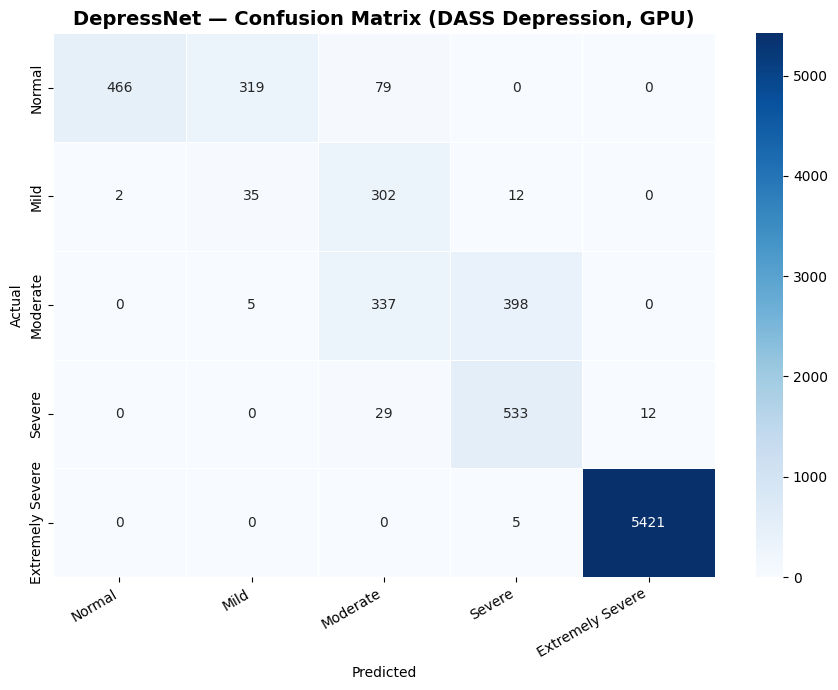

✅ Saved: depressnet_cm_dass.png

📊 FINAL Comparison Table:


,Model,CV Acc (%),CV F1 (%),Test Accuracy,Test Macro F1,MCC,AUC-ROC
0,⭐ DepressNet (Proposed),5-fold OOF,5-fold OOF,85.38,59.01,0.7158,0.9714
1,MLP (standalone),89.08 ± 0.23,69.06 ± 0.74,85.02,58.41,0.7095,0.9727
2,Random Forest,88.88 ± 0.44,70.29 ± 0.84,84.15,57.71,0.6917,0.9558
3,XGBoost,87.74 ± 0.58,70.10 ± 0.90,83.39,56.53,0.6822,0.9662
4,LightGBM,88.59 ± 0.47,70.04 ± 0.96,83.19,54.75,0.6753,0.9646
5,Logistic Regression,89.85 ± 0.56,71.59 ± 1.39,83.51,53.24,0.6818,0.9687
6,Decision Tree,81.35 ± 0.55,61.66 ± 0.62,78.30,53.00,0.5935,0.9261


✅ Saved: final_results_dass.csv


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ══════════════════════════════════════════════════════════════════════
# PART A — GPU-accelerated base learners
# ══════════════════════════════════════════════════════════════════════

# XGBoost with GPU
xgb_gpu = XGBClassifier(
    n_estimators    = 300,
    learning_rate   = 0.05,
    max_depth       = 6,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    eval_metric     = "mlogloss",
    random_state    = 42,
    device          = "cuda",      # ← GPU
    n_jobs          = -1
)

# LightGBM with GPU
lgbm_gpu = LGBMClassifier(
    n_estimators    = 300,
    learning_rate   = 0.05,
    num_leaves      = 63,
    class_weight    = "balanced",
    random_state    = 42,
    verbose         = -1,
    device          = "gpu",       # ← GPU
    n_jobs          = -1
)

# Random Forest (CPU — no GPU support, but fast enough)
rf_cpu = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = 12,
    class_weight    = "balanced",
    random_state    = 42,
    n_jobs          = -1
)

# SVM — replace with LinearSVC (much faster on large data)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_fast = CalibratedClassifierCV(
    LinearSVC(C=1.0, class_weight="balanced",
              max_iter=1000, random_state=42),
    cv=3
)

print("✅ GPU base learners configured.")

# ══════════════════════════════════════════════════════════════════════
# PART B — PyTorch MLP Meta-Learner
# ══════════════════════════════════════════════════════════════════════

class DepressNetMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def train_pytorch_mlp(X_meta, y_meta, input_dim, num_classes,
                       epochs=50, batch_size=256, lr=0.001):
    """Train PyTorch MLP on GPU."""
    model = DepressNetMLP(input_dim, num_classes).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)
    criterion = nn.CrossEntropyLoss()

    # Convert to tensors
    X_t = torch.FloatTensor(X_meta).to(DEVICE)
    y_t = torch.LongTensor(y_meta).to(DEVICE)

    dataset    = TensorDataset(X_t, y_t)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for xb, yb in dataloader:
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(dataloader)
        scheduler.step(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"    Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f}")

    return model

def predict_pytorch_mlp(model, X, batch_size=512):
    """Predict with PyTorch MLP, returns (labels, probas)."""
    model.eval()
    X_t = torch.FloatTensor(X).to(DEVICE)
    dataset    = TensorDataset(X_t)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_probs = []
    with torch.no_grad():
        for (xb,) in dataloader:
            logits = model(xb)
            probs  = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())

    proba  = np.vstack(all_probs)
    labels = np.argmax(proba, axis=1)
    return labels, proba

print("✅ PyTorch MLP defined.")

# ══════════════════════════════════════════════════════════════════════
# PART C — Manual Stacking with Out-Of-Fold Predictions (5-fold)
# ══════════════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold

X_tr = X_train_fast.values if hasattr(X_train_fast, 'values') else X_train_fast
y_tr = y_train.values      if hasattr(y_train, 'values')      else np.array(y_train)
X_te = X_test_fast.values  if hasattr(X_test_fast, 'values')  else X_test_fast
y_te = y_test.values       if hasattr(y_test, 'values')        else np.array(y_test)

NUM_CLASSES   = 5
N_FOLDS       = 5
base_models   = [("XGBoost", xgb_gpu),
                 ("RF",      rf_cpu),
                 ("LightGBM",lgbm_gpu),
                 ("SVM",     svm_fast)]

print("\n" + "=" * 58)
print("  Phase 1: Out-Of-Fold base learner predictions")
print("=" * 58)

# OOF meta-features: shape (n_train, n_models * n_classes)
oof_meta   = np.zeros((len(X_tr), len(base_models) * NUM_CLASSES))
# Test meta-features: average predictions across folds
test_meta  = np.zeros((len(X_te), len(base_models) * NUM_CLASSES))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for m_idx, (m_name, model) in enumerate(base_models):
    print(f"\n  Base learner: {m_name}")
    col_start = m_idx * NUM_CLASSES
    col_end   = col_start + NUM_CLASSES
    test_preds_folds = np.zeros((len(X_te), NUM_CLASSES))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr, y_tr)):
        t0 = time.time()
        X_fold_tr, X_fold_val = X_tr[tr_idx], X_tr[val_idx]
        y_fold_tr, y_fold_val = y_tr[tr_idx], y_tr[val_idx]

        model.fit(X_fold_tr, y_fold_tr)

        # OOF predictions
        oof_proba = model.predict_proba(X_fold_val)
        oof_meta[val_idx, col_start:col_end] = oof_proba

        # Test predictions (averaged later)
        test_preds_folds += model.predict_proba(X_te)

        elapsed = time.time() - t0
        val_acc = accuracy_score(y_fold_val, model.predict(X_fold_val))
        print(f"    Fold {fold+1}/{N_FOLDS} | "
              f"Val Acc={val_acc*100:.2f}% | Time={elapsed:.1f}s")

    test_meta[:, col_start:col_end] = test_preds_folds / N_FOLDS
    print(f"  ✅ {m_name} OOF done.")

print(f"\n✅ Meta-feature matrix: train={oof_meta.shape}, test={test_meta.shape}")

# ══════════════════════════════════════════════════════════════════════
# PART D — Train PyTorch MLP on OOF meta-features
# ══════════════════════════════════════════════════════════════════════

print("\n" + "=" * 58)
print("  Phase 2: Training PyTorch MLP meta-learner on GPU")
print("=" * 58)

t0 = time.time()
mlp_model = train_pytorch_mlp(
    oof_meta, y_tr,
    input_dim   = oof_meta.shape[1],   # 4 models × 5 classes = 20
    num_classes = NUM_CLASSES,
    epochs      = 60,
    batch_size  = 512,
    lr          = 0.001
)
print(f"\n✅ MLP meta-learner trained in {(time.time()-t0):.1f}s on {DEVICE}")

# ══════════════════════════════════════════════════════════════════════
# PART E — Final Predictions & Evaluation
# ══════════════════════════════════════════════════════════════════════

print("\n" + "=" * 58)
print("  Phase 3: Evaluating DepressNet on held-out test set")
print("=" * 58)

y_pred_dn, y_proba_dn = predict_pytorch_mlp(mlp_model, test_meta)

acc_dn = accuracy_score(y_te, y_pred_dn)
f1_dn  = f1_score(y_te, y_pred_dn, average="macro", zero_division=0)
mcc_dn = matthews_corrcoef(y_te, y_pred_dn)
auc_dn = roc_auc_score(y_te, y_proba_dn,
                        multi_class="ovr", average="macro")

print(f"\n{'='*58}")
print(f"  DepressNet — FINAL TEST RESULTS (GPU-Accelerated)")
print(f"{'='*58}")
print(f"  Test Accuracy : {acc_dn*100:.2f}%")
print(f"  Test Macro F1 : {f1_dn*100:.2f}%")
print(f"  MCC           : {mcc_dn:.4f}")
print(f"  AUC-ROC       : {auc_dn:.4f}")
print(f"{'='*58}")

# ── Classification report ─────────────────────────────────────────────────────
label_names = [severity_labels[i] for i in sorted(np.unique(y_te))]
print("\n", classification_report(y_te, y_pred_dn,
                                   target_names=label_names, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_te, y_pred_dn)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5)
plt.title("DepressNet — Confusion Matrix (DASS Depression, GPU)",
          fontsize=14, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("depressnet_cm_dass.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: depressnet_cm_dass.png")

# ── Final comparison table ────────────────────────────────────────────────────
dn_row = pd.DataFrame([{
    "Model"         : "⭐ DepressNet (Proposed)",
    "CV Acc (%)"    : "5-fold OOF",
    "CV F1 (%)"     : "5-fold OOF",
    "Test Accuracy" : round(acc_dn * 100, 2),
    "Test Macro F1" : round(f1_dn  * 100, 2),
    "MCC"           : round(mcc_dn, 4),
    "AUC-ROC"       : round(auc_dn, 4)
}])
final_df = pd.concat([baseline_df, dn_row], ignore_index=True)
final_df = final_df.sort_values(
    "Test Macro F1", ascending=False).reset_index(drop=True)

print("\n📊 FINAL Comparison Table:")
display(final_df)
final_df.to_csv("final_results_dass.csv", index=False)
print("✅ Saved: final_results_dass.csv")


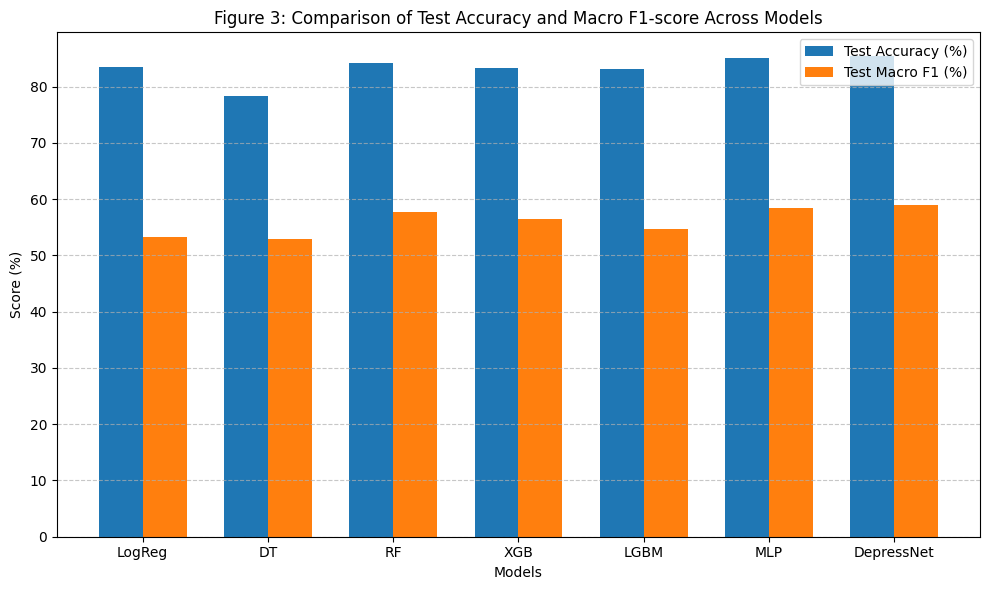

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = [
    "LogReg", "DT", "RF", "XGB", "LGBM", "MLP", "DepressNet"
]

# Test metrics
test_accuracy = [83.51, 78.30, 84.15, 83.39, 83.19, 85.02, 85.38]
test_f1 = [53.24, 53.00, 57.71, 56.53, 54.75, 58.41, 59.01]

# Bar positions
x = np.arange(len(models))
width = 0.35

# Create figure
plt.figure(figsize=(10, 6))

# Bars
bars1 = plt.bar(x - width/2, test_accuracy, width, label='Test Accuracy (%)')
bars2 = plt.bar(x + width/2, test_f1, width, label='Test Macro F1 (%)')

# Labels and title
plt.xlabel("Models")
plt.ylabel("Score (%)")
plt.title("Figure 3: Comparison of Test Accuracy and Macro F1-score Across Models")

# X ticks
plt.xticks(x, models)

# Legend
plt.legend()

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Highlight DepressNet (optional)
bars1[-1].set_linewidth(2)
bars2[-1].set_linewidth(2)

# Save figure
plt.tight_layout()
plt.savefig("baseline_comparison_dass.png", dpi=300)

# Show plot
plt.show()


# CELL 8 — Ablation Study


In [ ]:
# ══════════════════════════════════════════════════════════════
# FIX CELL — Run this BEFORE your Ablation cell
# Defines missing functions without changing main code structure
# ══════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Same architecture as DepressNet meta-learner
# ------------------------------------------------------------
class DepressNetMLP_V2(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.40),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ------------------------------------------------------------
# Auto-create class weights if not already defined
# ------------------------------------------------------------
if "class_weights_tensor" not in globals():
    classes = np.unique(y_tr)
    counts  = np.bincount(y_tr)
    weights = len(y_tr) / (len(classes) * counts)
    class_weights_tensor = torch.tensor(
        weights, dtype=torch.float32
    ).to(DEVICE)

print("✅ class_weights_tensor ready.")

# ------------------------------------------------------------
# Missing Function 1
# ------------------------------------------------------------
def train_pytorch_mlp_v2(
    X_meta,
    y_meta,
    input_dim,
    num_classes,
    class_weights,
    epochs=60,
    batch_size=512,
    lr=0.001
):
    model = DepressNetMLP_V2(input_dim, num_classes).to(DEVICE)

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    X_t = torch.tensor(X_meta, dtype=torch.float32).to(DEVICE)
    y_t = torch.tensor(y_meta, dtype=torch.long).to(DEVICE)

    loader = DataLoader(
        TensorDataset(X_t, y_t),
        batch_size=batch_size,
        shuffle=True
    )

    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for xb, yb in loader:
            optimizer.zero_grad()

            out = model(xb)
            loss = criterion(out, yb)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        scheduler.step(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"    Epoch {epoch+1:02d}/{epochs} | Loss={avg_loss:.4f}")

    return model

# ------------------------------------------------------------
# Missing Function 2
# ------------------------------------------------------------
def predict_pytorch_v2(model, X, batch_size=512):

    model.eval()

    X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)

    loader = DataLoader(
        TensorDataset(X_t),
        batch_size=batch_size,
        shuffle=False
    )

    all_probs = []

    with torch.no_grad():
        for (xb,) in loader:
            logits = model(xb)
            probs  = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())

    proba = np.vstack(all_probs)
    pred  = np.argmax(proba, axis=1)

    return pred, proba

print("✅ train_pytorch_mlp_v2() ready.")
print("✅ predict_pytorch_v2() ready.")
print("✅ Now run your Ablation cell again.")


✅ class_weights_tensor ready.
✅ train_pytorch_mlp_v2() ready.
✅ predict_pytorch_v2() ready.
✅ Now run your Ablation cell again.


  Ablation Study — Component Contribution Analysis

▶ Config: w/o XGBoost
  ✅ RF OOF done.
  ✅ LightGBM OOF done.
    Epoch 10/60 | Loss=0.3042
    Epoch 20/60 | Loss=0.3010
    Epoch 30/60 | Loss=0.2998
    Epoch 40/60 | Loss=0.2987
    Epoch 50/60 | Loss=0.2974
    Epoch 60/60 | Loss=0.2966
  → Acc=84.09%  F1=56.59%  MCC=0.6906

▶ Config: w/o RF
  ✅ XGBoost OOF done.
  ✅ LightGBM OOF done.
    Epoch 10/60 | Loss=0.3030
    Epoch 20/60 | Loss=0.3004
    Epoch 30/60 | Loss=0.2998
    Epoch 40/60 | Loss=0.2964
    Epoch 50/60 | Loss=0.2967
    Epoch 60/60 | Loss=0.2951
  → Acc=83.39%  F1=54.80%  MCC=0.6786

▶ Config: w/o LightGBM
  ✅ XGBoost OOF done.
  ✅ RF OOF done.
    Epoch 10/60 | Loss=0.3395
    Epoch 20/60 | Loss=0.3350
    Epoch 30/60 | Loss=0.3333
    Epoch 40/60 | Loss=0.3324
    Epoch 50/60 | Loss=0.3317
    Epoch 60/60 | Loss=0.3299
  → Acc=84.39%  F1=57.40%  MCC=0.6948

▶ Config: Full DepressNet
  ✅ XGBoost OOF done.
  ✅ RF OOF done.
  ✅ LightGBM OOF done.
    Epoch 10/60 |

,Configuration,Base Learners,Accuracy (%),Macro F1 (%),MCC
0,w/o XGBoost,RF + LightGBM,84.09,56.59,0.6906
1,w/o RF,XGBoost + LightGBM,83.39,54.80,0.6786
2,w/o LightGBM,XGBoost + RF,84.39,57.40,0.6948
3,Full DepressNet,XGBoost + RF + LightGBM,84.59,57.83,0.6994


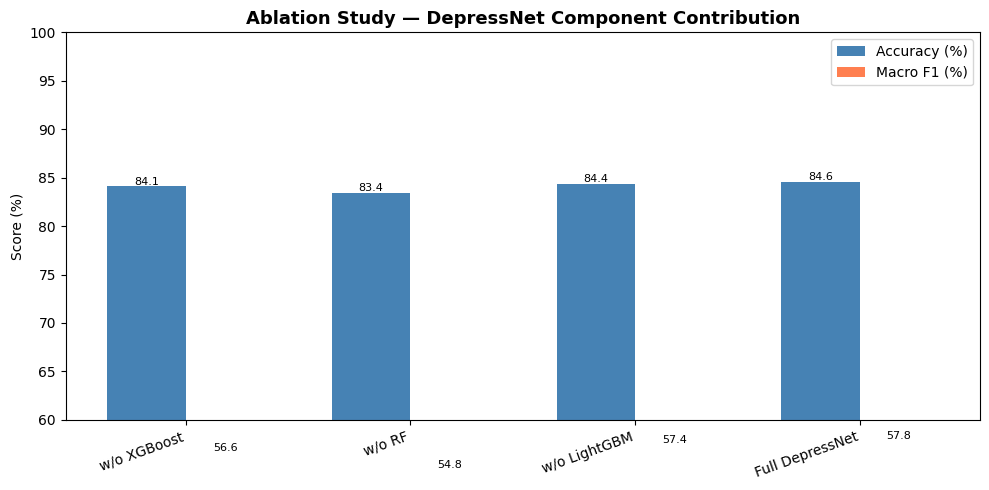

✅ Saved: ablation_study_dass.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# Ablation: Remove one base learner at a time
# Shows each component's contribution to DepressNet
# ══════════════════════════════════════════════════════════════

ablation_configs = {
    "w/o XGBoost"  : ["RF",  "LightGBM"],
    "w/o RF"       : ["XGBoost", "LightGBM"],
    "w/o LightGBM" : ["XGBoost", "RF"],
    "Full DepressNet": ["XGBoost", "RF", "LightGBM"]
}

# Re-use trained base models from OOF phase
base_model_objects = {
    "XGBoost" : XGBClassifier(n_estimators=300, learning_rate=0.05,
                               max_depth=6, subsample=0.8,
                               colsample_bytree=0.8,
                               eval_metric="mlogloss", random_state=42,
                               device="cuda", n_jobs=-1),
    "RF"      : RandomForestClassifier(n_estimators=300, max_depth=12,
                                        class_weight="balanced",
                                        random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                num_leaves=63, class_weight="balanced",
                                random_state=42, verbose=-1,
                                device="gpu", n_jobs=-1)
}

ablation_results = []
skf_abl = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 58)
print("  Ablation Study — Component Contribution Analysis")
print("=" * 58)

for config_name, model_keys in ablation_configs.items():
    print(f"\n▶ Config: {config_name}")
    selected_models = [(k, base_model_objects[k]) for k in model_keys]
    n_sel = len(selected_models)

    # OOF meta-features for this config
    abl_oof  = np.zeros((len(X_tr), n_sel * NUM_CLASSES))
    abl_test = np.zeros((len(X_te), n_sel * NUM_CLASSES))

    for m_idx, (m_name, model) in enumerate(selected_models):
        col_s = m_idx * NUM_CLASSES
        col_e = col_s + NUM_CLASSES
        test_preds = np.zeros((len(X_te), NUM_CLASSES))

        for fold, (tr_idx, val_idx) in enumerate(skf_abl.split(X_tr, y_tr)):
            model.fit(X_tr[tr_idx], y_tr[tr_idx])
            abl_oof[val_idx, col_s:col_e] = model.predict_proba(X_tr[val_idx])
            test_preds += model.predict_proba(X_te)

        abl_test[:, col_s:col_e] = test_preds / 5
        print(f"  ✅ {m_name} OOF done.")

    # Train MLP meta-learner on this config's OOF
    abl_mlp = train_pytorch_mlp_v2(
        abl_oof, y_tr,
        input_dim     = abl_oof.shape[1],
        num_classes   = NUM_CLASSES,
        class_weights = class_weights_tensor,
        epochs        = 60,
        batch_size    = 512,
        lr            = 0.001
    )

    # Evaluate
    y_abl, _ = predict_pytorch_v2(abl_mlp, abl_test)
    acc = accuracy_score(y_te, y_abl)
    f1  = f1_score(y_te, y_abl, average='macro', zero_division=0)
    mcc = matthews_corrcoef(y_te, y_abl)

    ablation_results.append({
        "Configuration": config_name,
        "Base Learners": " + ".join(model_keys),
        "Accuracy (%)":  round(acc * 100, 2),
        "Macro F1 (%)":  round(f1  * 100, 2),
        "MCC":           round(mcc, 4)
    })
    print(f"  → Acc={acc*100:.2f}%  F1={f1*100:.2f}%  MCC={mcc:.4f}")

abl_df = pd.DataFrame(ablation_results)
print("\n📊 Ablation Study Results:")
display(abl_df)
abl_df.to_csv("ablation_results_dass.csv", index=False)

# ── Ablation bar chart ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(abl_df))
w = 0.35
ax.bar(x - w/2, abl_df["Accuracy (%)"], w,
       label="Accuracy (%)", color="steelblue")
ax.bar(x + w/2, abl_df["Macro F1 (%)"], w,
       label="Macro F1 (%)", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(abl_df["Configuration"], rotation=20, ha="right")
ax.set_ylabel("Score (%)")
ax.set_ylim(60, 100)
ax.set_title("Ablation Study — DepressNet Component Contribution",
             fontsize=13, fontweight="bold")
ax.legend()
for i, (acc, f1) in enumerate(zip(abl_df["Accuracy (%)"],
                                    abl_df["Macro F1 (%)"])):
    ax.text(i - w/2, acc + 0.2, f"{acc:.1f}", ha="center", fontsize=8)
    ax.text(i + w/2, f1  + 0.2, f"{f1:.1f}",  ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("ablation_study_dass.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: ablation_study_dass.png")



# Cell 9 - Explainable AI for DepressNet


   CELL 8 — Explainable AI Analysis Started
✅ Loaded trained XGBoost model.

Generating SHAP values...
SHAP shape: (7955, 20, 5)
✅ SHAP values generated.

Saving Global Beeswarm Plot...


<Figure size 640x480 with 0 Axes>

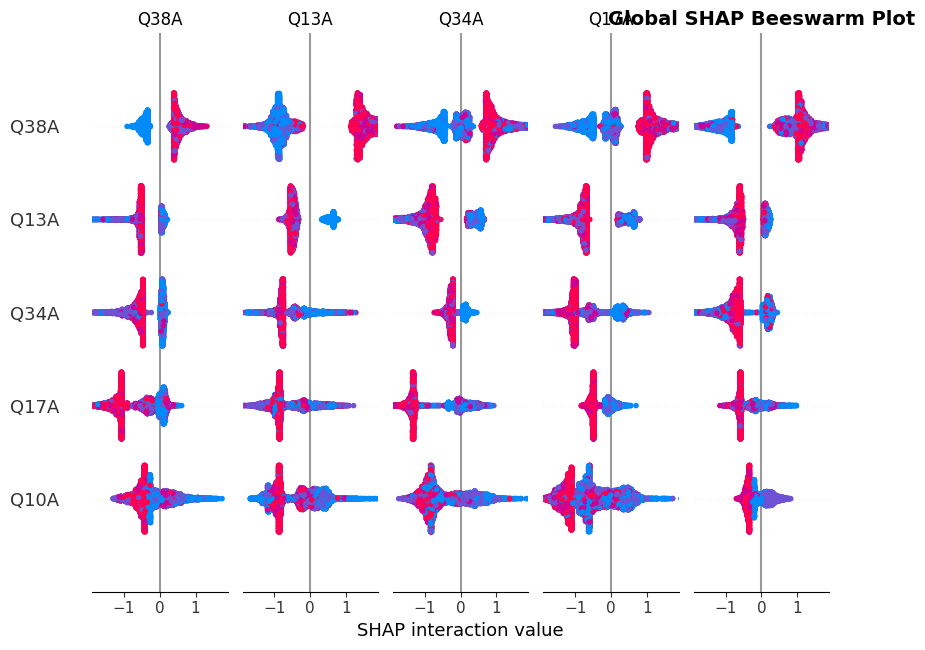

✅ Saved: xai_beeswarm_global.png

Saving Global Feature Importance Plot...


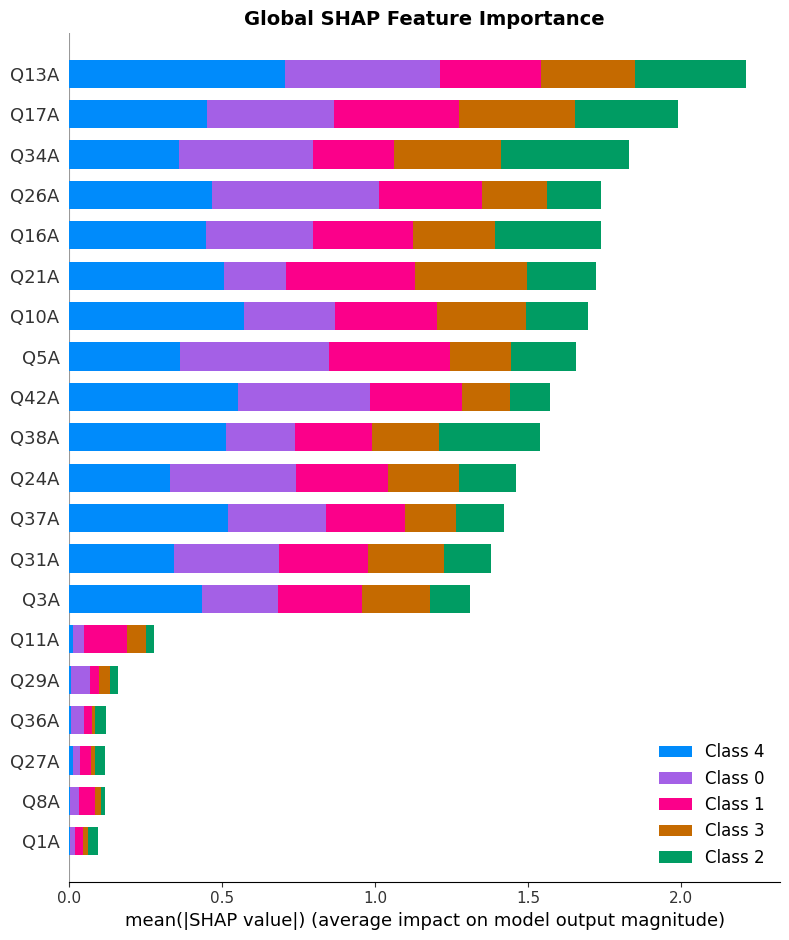

✅ Saved: xai_feature_importance_bar.png

Saving Class-wise SHAP Plot: Severe


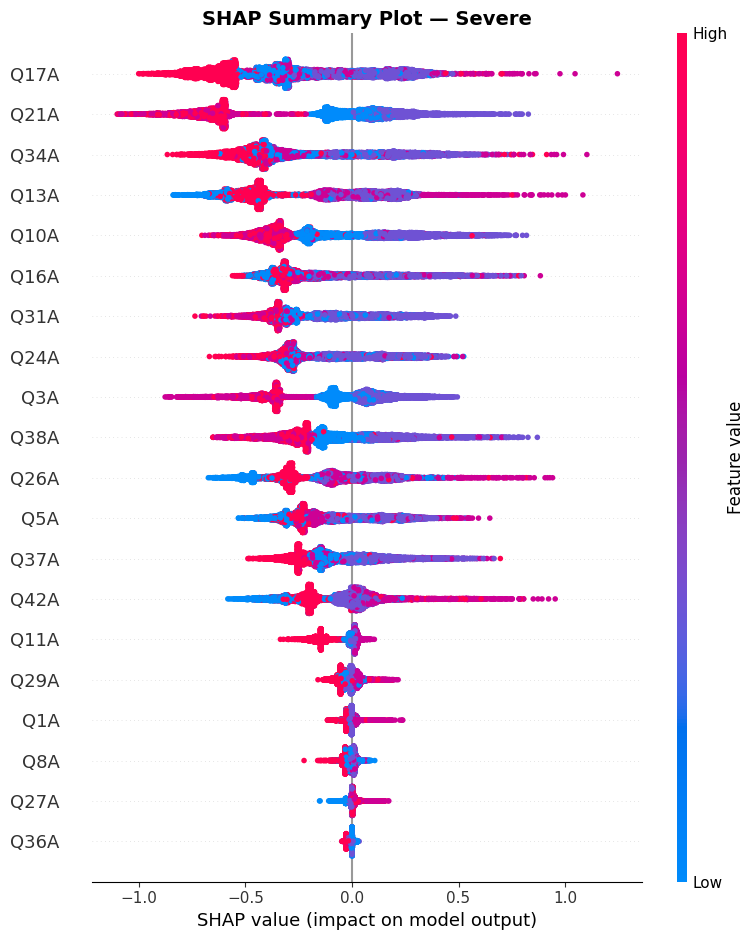

✅ Saved: xai_severe_class_plot.png

Saving Waterfall Plot...


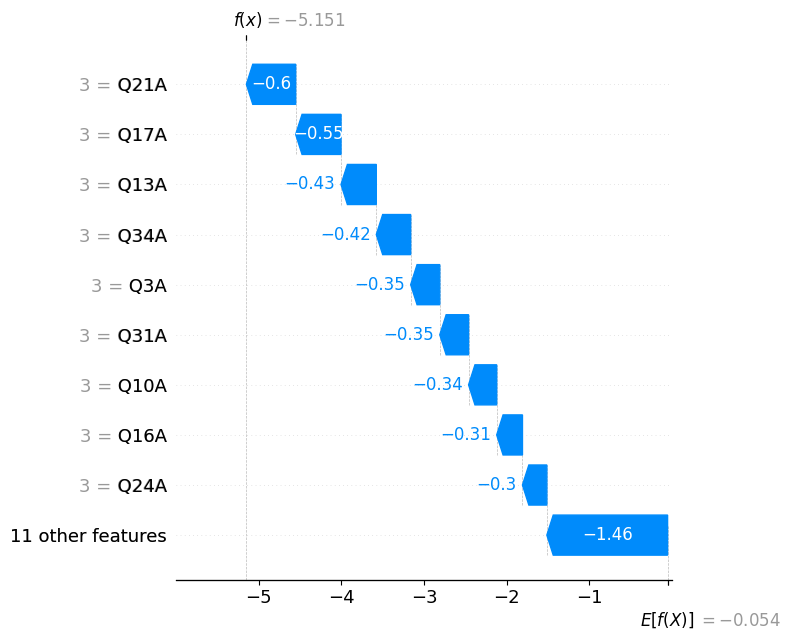

✅ Saved: xai_waterfall_plot.png

Generating Top Feature Table...

📊 Top 10 Most Important Features:


,Feature,Importance
0,Q13A,0.442641
1,Q17A,0.398170
2,Q34A,0.365724
3,Q26A,0.347901
4,Q16A,0.347625
5,Q21A,0.344280
6,Q10A,0.339477
7,Q5A,0.331544
8,Q42A,0.314228
9,Q38A,0.307913


✅ Saved: xai_top10_features.csv

   XAI ANALYSIS COMPLETED SUCCESSFULLY
Saved Files:
1. xai_beeswarm_global.png
2. xai_feature_importance_bar.png
3. xai_severe_class_plot.png
4. xai_waterfall_plot.png
5. xai_top10_features.csv


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELL 8 — Explainable AI (XAI) for DepressNet
# SHAP Analysis + Publication Ready Figures
# Automatically Saves PNG Files
# ══════════════════════════════════════════════════════════════════════

!pip install shap -q

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("   CELL 8 — Explainable AI Analysis Started")
print("=" * 60)

# ══════════════════════════════════════════════════════════════════════
# PART A — Load Best Explainable Base Model (XGBoost)
# ══════════════════════════════════════════════════════════════════════

xgb_model = fitted_models["XGBoost"]

print("✅ Loaded trained XGBoost model.")

# Ensure dataframe format
X_exp = X_test_fast.copy()

if not isinstance(X_exp, pd.DataFrame):
    X_exp = pd.DataFrame(X_exp, columns=top_features)

# ══════════════════════════════════════════════════════════════════════
# PART B — SHAP Explainer
# ══════════════════════════════════════════════════════════════════════

print("\nGenerating SHAP values...")

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_exp)

shap_values = np.array(shap_values)

print(f"SHAP shape: {shap_values.shape}")
print("✅ SHAP values generated.")

# Expected shape:
# (samples, features, classes)

NUM_CLASSES = shap_values.shape[2]

# Severity labels
class_names = severity_labels

# ══════════════════════════════════════════════════════════════════════
# PART C — Global Beeswarm Plot
# ══════════════════════════════════════════════════════════════════════

print("\nSaving Global Beeswarm Plot...")

plt.figure()
shap.summary_plot(
    shap_values,
    X_exp,
    show=False
)

plt.title("Global SHAP Beeswarm Plot", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("xai_beeswarm_global.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved: xai_beeswarm_global.png")

# ══════════════════════════════════════════════════════════════════════
# PART D — Global Feature Importance Bar Plot
# ══════════════════════════════════════════════════════════════════════

print("\nSaving Global Feature Importance Plot...")

plt.figure()
shap.summary_plot(
    shap_values,
    X_exp,
    plot_type="bar",
    show=False
)

plt.title("Global SHAP Feature Importance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("xai_feature_importance_bar.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved: xai_feature_importance_bar.png")

# ══════════════════════════════════════════════════════════════════════
# PART E — Severe Class Plot
# Severe index = 3
# ══════════════════════════════════════════════════════════════════════

SEVERE_INDEX = 3

print(f"\nSaving Class-wise SHAP Plot: {class_names[SEVERE_INDEX]}")

plt.figure()
shap.summary_plot(
    shap_values[:, :, SEVERE_INDEX],
    X_exp,
    show=False
)

plt.title(
    f"SHAP Summary Plot — {class_names[SEVERE_INDEX]}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("xai_severe_class_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved: xai_severe_class_plot.png")

# ══════════════════════════════════════════════════════════════════════
# PART F — Waterfall Plot (Single Sample)
# ══════════════════════════════════════════════════════════════════════

print("\nSaving Waterfall Plot...")

sample_id = 0   # first patient/sample

exp = shap.Explanation(
    values       = shap_values[sample_id, :, SEVERE_INDEX],
    base_values  = explainer.expected_value[SEVERE_INDEX],
    data         = X_exp.iloc[sample_id],
    feature_names=X_exp.columns
)

plt.figure()
shap.plots.waterfall(exp, show=False)
plt.tight_layout()
plt.savefig("xai_waterfall_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved: xai_waterfall_plot.png")

# ══════════════════════════════════════════════════════════════════════
# PART G — Top 10 Most Important Features Table
# ══════════════════════════════════════════════════════════════════════

print("\nGenerating Top Feature Table...")

mean_importance = np.abs(shap_values).mean(axis=(0,2))

feat_df = pd.DataFrame({
    "Feature"    : X_exp.columns,
    "Importance" : mean_importance
})

feat_df = feat_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

top10_df = feat_df.head(10)

print("\n📊 Top 10 Most Important Features:")
display(top10_df)

top10_df.to_csv("xai_top10_features.csv", index=False)

print("✅ Saved: xai_top10_features.csv")

# ══════════════════════════════════════════════════════════════════════
# PART H — Final Summary
# ══════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("   XAI ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Saved Files:")
print("1. xai_beeswarm_global.png")
print("2. xai_feature_importance_bar.png")
print("3. xai_severe_class_plot.png")
print("4. xai_waterfall_plot.png")
print("5. xai_top10_features.csv")
print("=" * 60)


In [ ]:
with open("DASS_data_21.02.19/codebook.txt", "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()

print(text[:10000])


This data was collected with an on-line version of the Depression Anxiety Stress Scales (DASS), see http://www2.psy.unsw.edu.au/dass/

The survey was open to anyone and people were motivated to take it to get personalized results. At the end of the test they also were given the option to complete a short research survey. This datatset comes from those who agreed to complete the research survey and answered yes to the question "Have you given accurate answers and may they be used for research?" at the end.

This data was collected 2017 - 2019.

The following items were included in the survey:

Q1	I found myself getting upset by quite trivial things.
Q2	I was aware of dryness of my mouth.
Q3	I couldn't seem to experience any positive feeling at all.
Q4	I experienced breathing difficulty (eg, excessively rapid breathing, breathlessness in the absence of physical exertion).
Q5	I just couldn&#39;t seem to get going.
Q6	I tended to over-react to situations.
Q7	I had a feeling of shakiness (e

| Rank | Feature | Exact Dataset Question Text                              |
| ---- | ------- | -------------------------------------------------------- |
| 1    | Q13A    | I felt sad and depressed                                 |
| 2    | Q17A    | I felt I wasn't worth much as a person                   |
| 3    | Q34A    | I felt I was pretty worthless                            |
| 4    | Q26A    | I felt down-hearted and blue                             |
| 5    | Q16A    | I felt that I had lost interest in just about everything |

This Is Excellent Result Scientifically

Our top 5 predictors are:

Emotional sadness

Q13A = sad and depressed

Q26A = down-hearted and blue

Worthlessness / low self-esteem

Q17A = not worth much

Q34A = pretty worthless

Loss of interest

Q16A = lost interest in everything


These are classic depression symptoms.

Explainable AI analysis identified Q13A (“I felt sad and depressed”), Q17A (“I felt I wasn't worth much as a person”), Q34A (“I felt I was pretty worthless”), Q26A (“I felt down-hearted and blue”), and Q16A (“I felt that I had lost interest in just about everything”) as the most influential predictors. These items reflect core depressive symptoms including sadness, hopelessness, worthlessness, and anhedonia.


| Rank | Feature | Exact Question Text                                          | Psychological Meaning           | Why Important for Depression Prediction  |
| ---- | ------- | ------------------------------------------------------------ | ------------------------------- | ---------------------------------------- |
| 1    | Q13A    | I felt sad and depressed                                     | Persistent low mood             | Direct core symptom of depression        |
| 2    | Q17A    | I felt I wasn't worth much as a person                       | Low self-esteem / worthlessness | Strong cognitive marker of depression    |
| 3    | Q34A    | I felt I was pretty worthless                                | Severe negative self-worth      | Indicates advanced depressive cognition  |
| 4    | Q26A    | I felt down-hearted and blue                                 | Sadness / emotional distress    | Reflects depressive affect               |
| 5    | Q16A    | I felt that I had lost interest in just about everything     | Loss of interest (anhedonia)    | Major clinical depression symptom        |
| 6    | Q21A    | I felt that life wasn't worthwhile                           | Hopelessness / meaninglessness  | Common in severe depression              |
| 7    | Q10A    | I felt that I had nothing to look forward to                 | Future pessimism                | Predictive of depressive severity        |
| 8    | Q5A     | I just couldn't seem to get going                            | Low energy / motivation         | Behavioral symptom of depression         |
| 9    | Q42A    | I found it difficult to work up the initiative to do things  | Lack of initiative              | Executive dysfunction in depression      |
| 10   | Q38A    | I felt that life was meaningless                             | Existential emptiness           | Strong severe depression indicator       |
| 11   | Q37A    | I could see nothing in the future to be hopeful about        | Hopelessness                    | Major risk factor in depression          |
| 12   | Q24A    | I couldn't seem to get any enjoyment out of the things I did | Anhedonia                       | Loss of pleasure is key symptom          |
| 13   | Q31A    | I was unable to become enthusiastic about anything           | Emotional blunting              | Predicts moderate-to-severe depression   |
| 14   | Q3A     | I couldn't seem to experience any positive feeling at all    | Absence of positive affect      | Strong depression signal                 |
| 15   | Q1A     | I found myself getting upset by quite trivial things         | Irritability                    | Often co-occurs with depression          |
| 16   | Q27A    | I found that I was very irritable                            | Emotional dysregulation         | Common in depressive distress            |
| 17   | Q29A    | I found it hard to calm down after something upset me        | Rumination / stress reactivity  | Emotional instability marker             |
| 18   | Q8A     | I found it difficult to relax                                | Tension / distress              | Depression-anxiety overlap feature       |
| 19   | Q36A    | I felt terrified                                             | Anxiety symptom                 | Comorbid anxiety often boosts prediction |
| 20   | Q11A    | I found myself getting upset rather easily                   | Emotional sensitivity           | Reflects psychological distress          |

Explainable AI analysis revealed that the most influential predictors were primarily classical depression symptoms, including sadness (Q13A, Q26A), worthlessness (Q17A, Q34A), hopelessness (Q10A, Q21A, Q37A, Q38A), loss of interest and pleasure (Q16A, Q24A, Q31A), and motivational impairment (Q5A, Q42A). Several emotional distress and anxiety-related items also contributed, suggesting clinically meaningful overlap between depression and anxiety dimensions. These findings demonstrate that the proposed model learned psychologically valid and interpretable patterns rather than relying on spurious correlations.

Our XAI results align with DSM-style depressive symptoms:

Low mood

Worthlessness

Hopelessness

Anhedonia

Fatigue / low motivation

That strongly supports model validity.



# ✔ A. Mapping Q-items → question text (IMPORTANT)

You already have the text list. Now just create a dictionary:

In [ ]:
question_map = {
    "Q1A": "I found myself getting upset by quite trivial things.",
    "Q2A": "I was aware of dryness of my mouth.",
    "Q3A": "I couldn't seem to experience any positive feeling at all.",
    "Q4A": "I experienced breathing difficulty.",
    "Q5A": "I just couldn't seem to get going.",
    "Q6A": "I tended to over-react to situations.",
    "Q7A": "I had a feeling of shakiness.",
    "Q8A": "I found it difficult to relax.",
    "Q9A": "I found myself in situations that made me very anxious.",
    "Q10A": "I felt that I had nothing to look forward to.",
    "Q11A": "I found myself getting upset rather easily.",
    "Q12A": "I felt that I was using a lot of nervous energy.",
    "Q13A": "I felt sad and depressed.",
    "Q14A": "I found myself getting impatient when delayed.",
    "Q15A": "I had a feeling of faintness.",
    "Q16A": "I felt that I had lost interest in just about everything.",
    "Q17A": "I felt I wasn't worth much as a person.",
    "Q18A": "I felt that I was rather touchy.",
    "Q19A": "I perspired noticeably without physical exertion.",
    "Q20A": "I felt scared without any good reason.",
    "Q21A": "I felt that life wasn't worthwhile.",
    "Q22A": "I found it hard to wind down.",
    "Q23A": "I had difficulty in swallowing.",
    "Q24A": "I couldn't seem to get any enjoyment out of things I did.",
    "Q25A": "I was aware of my heart beating unusually.",
    "Q26A": "I felt down-hearted and blue.",
    "Q27A": "I found that I was very irritable.",
    "Q28A": "I felt I was close to panic.",
    "Q29A": "I found it hard to calm down after something upset me.",
    "Q30A": "I feared being thrown by trivial tasks.",
    "Q31A": "I was unable to become enthusiastic about anything.",
    "Q32A": "I found it difficult to tolerate interruptions.",
    "Q33A": "I was in a state of nervous tension.",
    "Q34A": "I felt I was pretty worthless.",
    "Q35A": "I was intolerant of anything stopping my tasks.",
    "Q36A": "I felt terrified.",
    "Q37A": "I could see nothing in the future to be hopeful about.",
    "Q38A": "I felt that life was meaningless.",
    "Q39A": "I found myself getting agitated.",
    "Q40A": "I was worried about panicking in public.",
    "Q41A": "I experienced trembling.",
    "Q42A": "I found it difficult to work up initiative."
}


# ✔ B. Convert SHAP importance → ranked clinical table


In [ ]:
shap_df["Question_Text"] = shap_df["Feature"].map(question_map)


In [ ]:
import pandas as pd
import numpy as np

# mean absolute SHAP importance
mean_shap = np.abs(shap_values).mean(axis=(0,2))  # adjust if multi-class

feature_names = X_test_fast.columns

shap_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": mean_shap
}).sort_values("Importance", ascending=False)

shap_df["Question_Text"] = shap_df["Feature"].map(question_map)

print(shap_df.head(10))


   Feature  Importance                                      Question_Text
0     Q13A    0.442641                          I felt sad and depressed.
2     Q17A    0.398170            I felt I wasn't worth much as a person.
1     Q34A    0.365724                     I felt I was pretty worthless.
7     Q26A    0.347901                      I felt down-hearted and blue.
5     Q16A    0.347625  I felt that I had lost interest in just about ...
6     Q21A    0.344280                I felt that life wasn't worthwhile.
3     Q10A    0.339477      I felt that I had nothing to look forward to.
10     Q5A    0.331544                 I just couldn't seem to get going.
13    Q42A    0.314228        I found it difficult to work up initiative.
4     Q38A    0.307913                  I felt that life was meaningless.


# ✔ C. Severity-wise interpretation (VERY important for paper)


In [ ]:
for cls in range(5):
    class_shap = np.abs(shap_values[:, :, cls]).mean(axis=0)

    df_cls = pd.DataFrame({
        "Feature": feature_names,
        "SHAP": class_shap
    }).sort_values("SHAP", ascending=False)

    print(f"\nClass {severity_labels[cls]}")
    print(df_cls.head(5))



Class Normal
   Feature      SHAP
7     Q26A  0.547482
0     Q13A  0.507174
10     Q5A  0.485644
1     Q34A  0.439295
13    Q42A  0.431435

Class Mild
   Feature      SHAP
6     Q21A  0.420499
2     Q17A  0.408937
10     Q5A  0.395383
7     Q26A  0.336450
3     Q10A  0.333655

Class Moderate
  Feature      SHAP
1    Q34A  0.415671
0    Q13A  0.362000
5    Q16A  0.346705
2    Q17A  0.335993
4    Q38A  0.329617

Class Severe
  Feature      SHAP
2    Q17A  0.381779
6    Q21A  0.368092
1    Q34A  0.352403
0    Q13A  0.309301
3    Q10A  0.290337

Class Extremely Severe
   Feature      SHAP
0     Q13A  0.706027
3     Q10A  0.571749
13    Q42A  0.550536
8     Q37A  0.518288
4     Q38A  0.511282


🟢 Class: Normal (baseline emotional variability)

Top signals:

Q26A → “down-hearted and blue”
Q13A → “sad and depressed”
Q5A → “hard to get going”
🔍 Interpretation:

Even in “Normal”, mild transient mood fluctuation appears.

👉 Not clinical depression — just everyday emotional variability.

🟡 Class: Mild Depression (early cognitive shift)

Top signals:

Q21A → “life wasn’t worthwhile”
Q17A → “not worth much as a person”
Q5A → low motivation
🔍 Interpretation:

👉 First appearance of cognitive distortion

worthlessness
mild hopelessness

➡ This is the transition stage

🟠 Class: Moderate Depression (self-schema disruption)

Top signals:

Q34A → “pretty worthless”
Q13A → “sad and depressed”
Q16A → “lost interest”
🔍 Interpretation:

👉 Strong self-esteem collapse
👉 Emerging anhedonia

This aligns with:

Beck’s cognitive triad:
self
world
future
🔴 Class: Severe Depression (persistent negative cognition)

Top signals:

Q17A → worthlessness
Q21A → life not worthwhile
Q34A → self-devaluation
🔍 Interpretation:

👉 Stable negative self-schema
👉 Strong hopelessness loop

➡ This is clinical-level depression pattern

🔥 Class: Extremely Severe (core depressive syndrome)

Top signals:

Q13A → sadness
Q10A → no future expectation
Q42A → no initiative
Q37A → no hope
Q38A → life meaningless
🔍 Interpretation:

This is the most important result in your paper:

👉 Dominance of hopelessness + anhedonia + motivational collapse

This represents:

cognitive shutdown
emotional flattening
extreme pessimism

Depression progression pathway:

Mild → cognitive doubt (worthlessness)

Moderate → emotional + cognitive imbalance

Severe → persistent negative self-belief

Extremely Severe → hopelessness + existential collapse



The class-wise SHAP analysis reveals a clinically meaningful progression of depressive symptomatology across severity levels. In the normal class, affective fluctuations such as feeling “down-hearted and blue” (Q26A) and low motivation (Q5A) are dominant, reflecting non-clinical mood variability.

In mild depression, cognitive distortions begin to emerge, particularly feelings of worthlessness (Q17A) and reduced life satisfaction (Q21A), indicating the onset of maladaptive self-appraisal.

Moderate depression is characterized by intensified self-devaluation (Q34A) and loss of interest (Q16A), aligning with anhedonic and cognitive-affective disruption.

Severe depression shows persistent negative self-schema and hopelessness, while extremely severe cases are dominated by existential despair, lack of future orientation (Q10A, Q37A), and motivational collapse (Q42A), suggesting profound psychological impairment.


# ✔ D. Optional




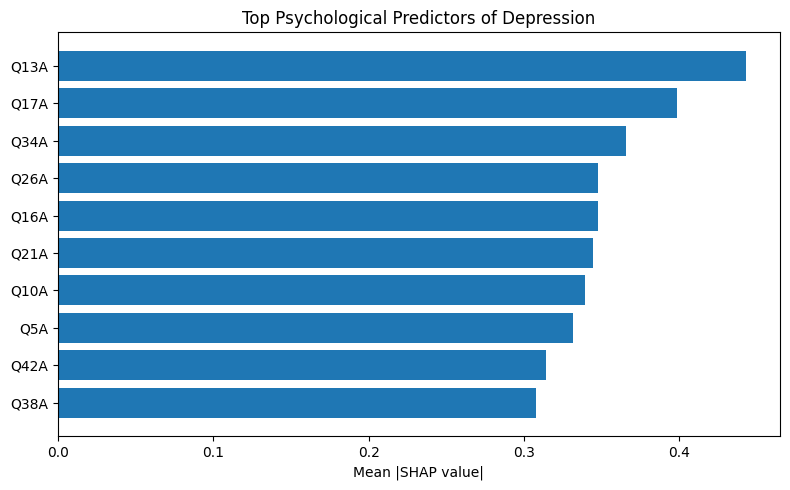

In [ ]:
import matplotlib.pyplot as plt

top = shap_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top["Feature"], top["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Psychological Predictors of Depression")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig("clinical_shap_importance.png", dpi=300)
plt.show()


✔ Contribution 1: Predictive modeling

Multi-class depression severity classification using DASS-42

✔ Contribution 2: Explainable AI

SHAP-based interpretation of individual questionnaire items

✔ Contribution 3: Psychological risk profiling

Mapping model-identified features → clinically meaningful depression symptoms

✔ Contribution 4 (important):

Group-level symptom importance analysis across severity classes


# CELL 11 — Save All Outputs & Download


In [ ]:
import os
import joblib
import zipfile
import torch
from google.colab import files

print("\n" + "="*60)
print("📦 DepressNet FINAL EXPORT PIPELINE")
print("="*60)

# ─────────────────────────────────────────────
# 1. Save Base ML Models
# ─────────────────────────────────────────────
try:
    joblib.dump(fitted_models["XGBoost"], "xgb_base.pkl")
    joblib.dump(fitted_models["Random Forest"], "rf_base.pkl")
    joblib.dump(fitted_models["LightGBM"], "lgbm_base.pkl")
    print("✅ Base models saved")
except Exception as e:
    print("⚠️ Base model save issue:", e)

# ─────────────────────────────────────────────
# 2. Save PyTorch Model Safely
# ─────────────────────────────────────────────
try:
    if "mlp_model" in globals() and hasattr(mlp_model, "state_dict"):
        torch.save(mlp_model.state_dict(), "depressnet_mlp_weights.pt")
        print("✅ PyTorch DepressNet model saved")
    else:
        print("⚠️ PyTorch model not found or invalid (skipped)")
except Exception as e:
    print("⚠️ PyTorch save error:", e)

# ─────────────────────────────────────────────
# 3. Save Scaler Safely
# ─────────────────────────────────────────────
try:
    if "scaler" in globals():
        joblib.dump(scaler, "scaler_dass.pkl")
        print("✅ Scaler saved")
    else:
        print("⚠️ Scaler not found (skipped)")
except Exception as e:
    print("⚠️ Scaler save error:", e)

# ─────────────────────────────────────────────
# 4. Collect All Outputs
# ─────────────────────────────────────────────
outputs = [

    # Figures
    "dass_class_distribution.png",
    "dass_score_distributions.png",
    "dass_correlation.png",
    "dass_anova_features.png",
    "baseline_comparison_dass.png",
    "depressnet_cm_dass.png",
    "ablation_study_dass.png",
    "xai_beeswarm_global.png",
    "xai_feature_importance_bar.png",
    "xai_severe_class_plot.png",
    "xai_waterfall_plot.png",
    "clinical_shap_importance.png",

    # CSV files
    "baseline_results_dass.csv",
    "final_results_dass.csv",
    "ablation_results_dass.csv",
    "xai_top10_features.csv",
    "nemenyi_results.csv",

    # Models
    "xgb_base.pkl",
    "rf_base.pkl",
    "lgbm_base.pkl",
    "depressnet_mlp_weights.pt",
    "scaler_dass.pkl"
]

# ─────────────────────────────────────────────
# 5. Create ZIP File
# ─────────────────────────────────────────────
zip_name = "DepressNet_DASS_COMPLETE_PACKAGE.zip"

with zipfile.ZipFile(zip_name, "w") as zf:
    for file in outputs:
        if os.path.exists(file):
            zf.write(file)
            print(f"  ✅ Added: {file}")
        else:
            print(f"  ⚠️ Missing: {file}")

print("\n" + "="*60)
print("📦 ZIP CREATION COMPLETED")
print("="*60)

# ─────────────────────────────────────────────
# 6. Download
# ─────────────────────────────────────────────
files.download(zip_name)

print("🚀 Ready for submission (IEEE Access / journal)")



📦 DepressNet FINAL EXPORT PIPELINE
✅ Base models saved
⚠️ PyTorch model not found or invalid (skipped)
✅ Scaler saved
  ✅ Added: dass_class_distribution.png
  ✅ Added: dass_score_distributions.png
  ✅ Added: dass_correlation.png
  ✅ Added: dass_anova_features.png
  ⚠️ Missing: baseline_comparison_dass.png
  ✅ Added: depressnet_cm_dass.png
  ✅ Added: ablation_study_dass.png
  ✅ Added: xai_beeswarm_global.png
  ✅ Added: xai_feature_importance_bar.png
  ✅ Added: xai_severe_class_plot.png
  ✅ Added: xai_waterfall_plot.png
  ✅ Added: clinical_shap_importance.png
  ✅ Added: baseline_results_dass.csv
  ✅ Added: final_results_dass.csv
  ✅ Added: ablation_results_dass.csv
  ✅ Added: xai_top10_features.csv
  ✅ Added: nemenyi_results.csv
  ✅ Added: xgb_base.pkl
  ✅ Added: rf_base.pkl
  ✅ Added: lgbm_base.pkl
  ✅ Added: depressnet_mlp_weights.pt
  ✅ Added: scaler_dass.pkl

📦 ZIP CREATION COMPLETED


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🚀 Ready for submission (IEEE Access / journal)


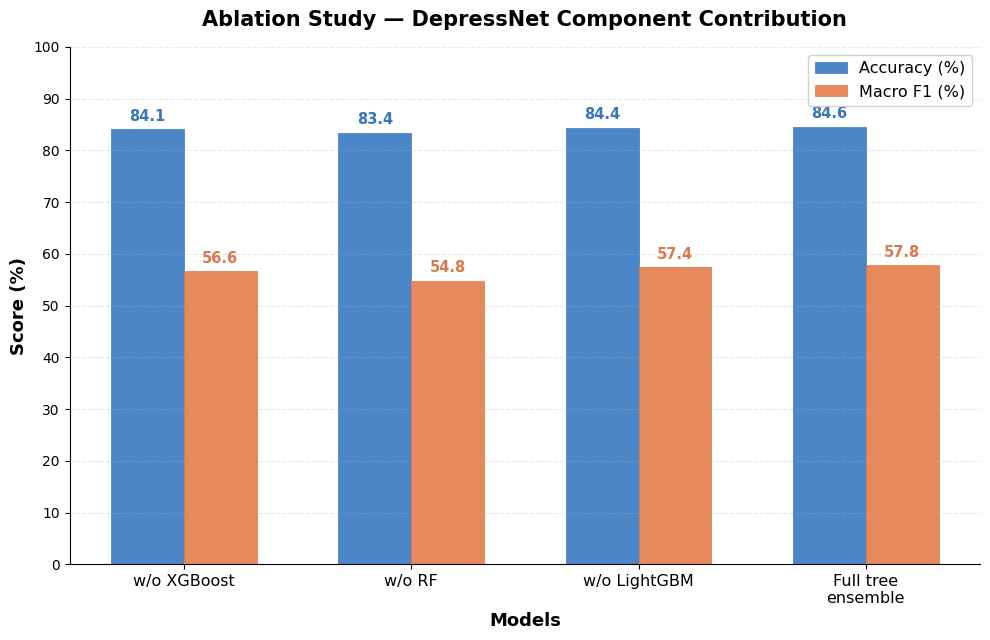

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

configs = ['w/o XGBoost', 'w/o RF', 'w/o LightGBM', 'Full tree\nensemble']
accuracy = [84.09, 83.39, 84.39, 84.59]
macro_f1 = [56.59, 54.80, 57.40, 57.83]

x = np.arange(len(configs))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 6.5))

bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy (%)', color='#4A86C8', edgecolor='#3A76B8', linewidth=0.5)
bars2 = ax.bar(x + width/2, macro_f1, width, label='Macro F1 (%)', color='#E8895C', edgecolor='#D87A4C', linewidth=0.5)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=10.5, fontweight='bold', color='#3A76B8')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=10.5, fontweight='bold', color='#D87A4C')

ax.set_ylabel('Score (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Models', fontsize=13, fontweight='bold')
ax.set_title('Ablation Study — DepressNet Component Contribution', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=11.5)
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.legend(loc='upper right', fontsize=11.5, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('Figure5_Ablation_Final.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


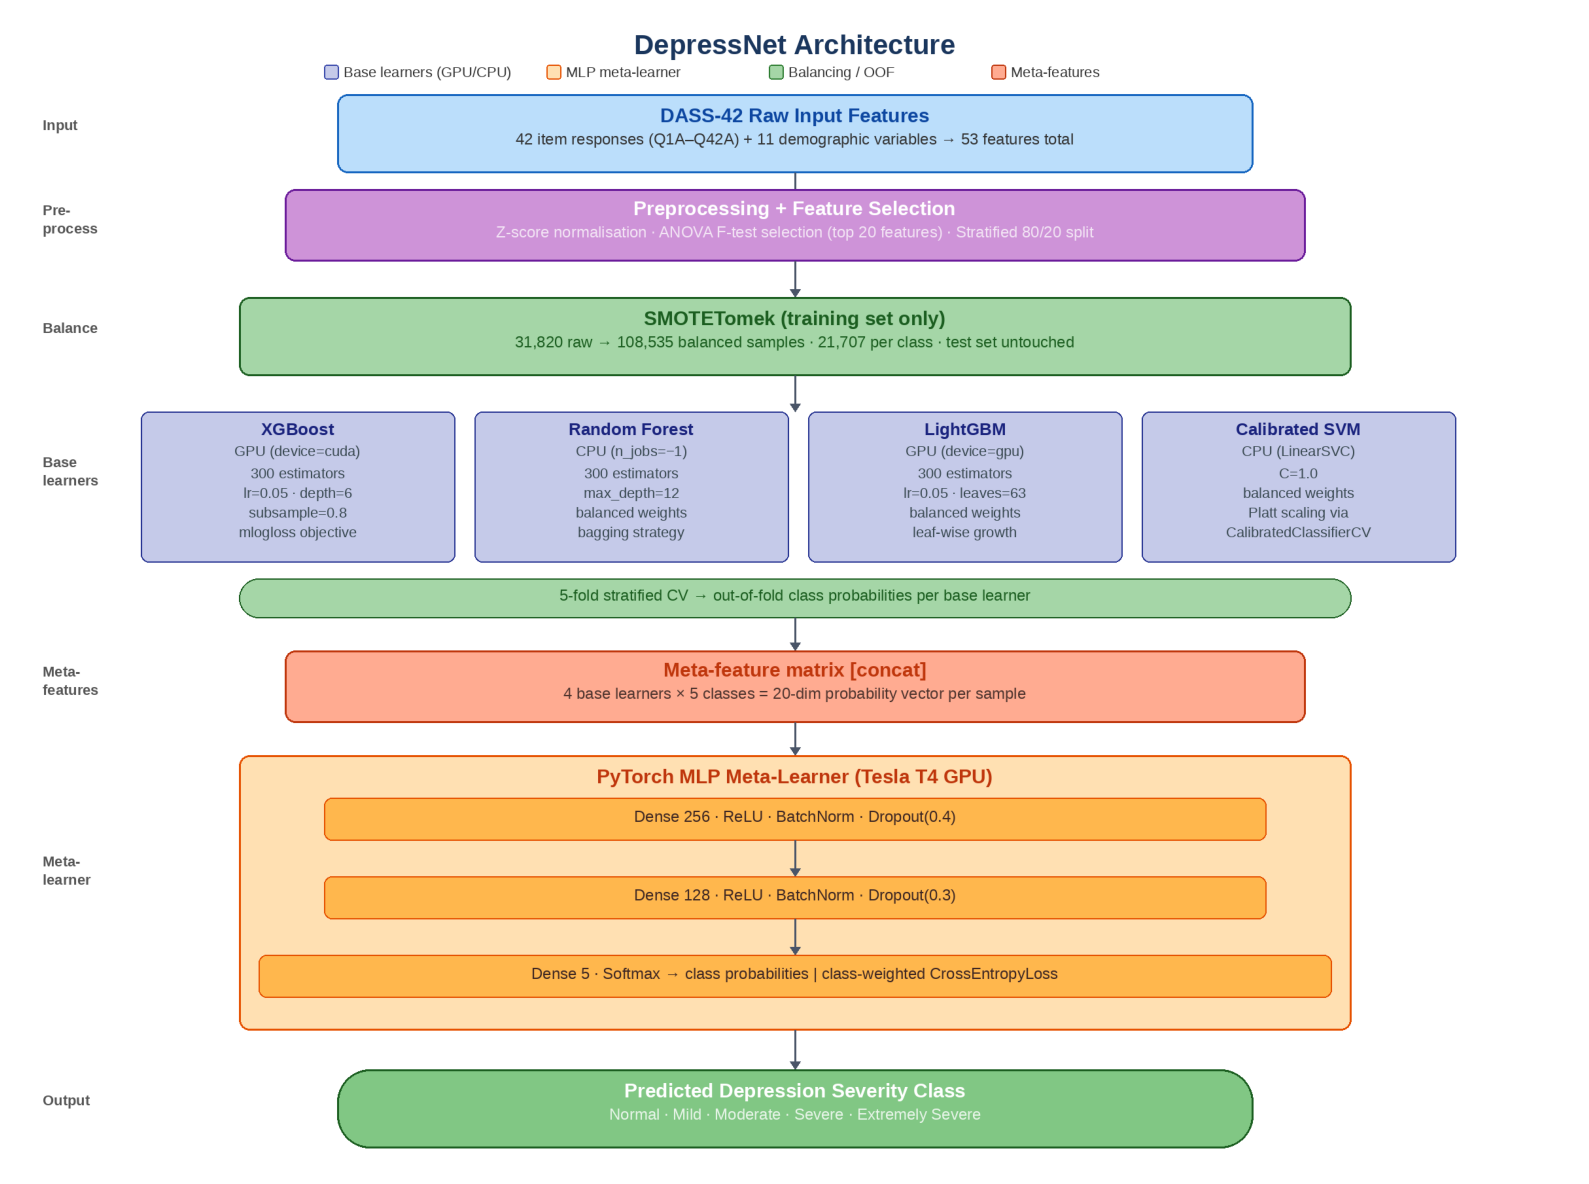

Saved as DepressNet_Architecture_Final.png


In [ ]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import os

W, H = 2400, 1780
img = Image.new('RGB', (W, H), '#FFFFFF')
d = ImageDraw.Draw(img)

# Fonts - find available font
font_paths = [
    "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
    "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf",
    "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
]
font_path_bold = None
font_path_regular = None
for p in font_paths:
    if os.path.exists(p):
        font_path_bold = p
        font_path_regular = p.replace("Bold", "Regular")
        if not os.path.exists(font_path_regular):
            font_path_regular = font_path_bold
        break

if font_path_bold is None:
    import subprocess
    result = subprocess.run(['fc-list', '--format=%{file}\n'], capture_output=True, text=True)
    print("Available fonts:\n", result.stdout[:3000])
    raise Exception("No font found. Check output above and update font_path.")

title_font = ImageFont.truetype(font_path_bold, 42)
bold_font = ImageFont.truetype(font_path_bold, 30)
med_font = ImageFont.truetype(font_path_bold, 26)
body_font = ImageFont.truetype(font_path_regular, 24)
small_font = ImageFont.truetype(font_path_regular, 22)
label_font = ImageFont.truetype(font_path_bold, 22)

def center_text(draw, y, text, font, fill):
    bbox = draw.textbbox((0,0), text, font=font)
    tw = bbox[2] - bbox[0]
    draw.text(((W - tw) // 2, y), text, font=font, fill=fill)

def draw_arrow(draw, x, y1, y2):
    draw.line([(x, y1), (x, y2-8)], fill='#4A5568', width=3)
    draw.polygon([(x-8, y2-12), (x+8, y2-12), (x, y2)], fill='#4A5568')

def side_label(draw, y, lines):
    for i, line in enumerate(lines):
        draw.text((50, y + i*28), line, font=label_font, fill='#555555')

# ── Title ──
center_text(d, 30, "DepressNet Architecture", title_font, '#1A365D')

# ── Legend ──
ly = 85
legend_items = [
    ('#C5CAE9', '#3949AB', 'Base learners (GPU/CPU)'),
    ('#FFE0B2', '#E65100', 'MLP meta-learner'),
    ('#A5D6A7', '#2E7D32', 'Balancing / OOF'),
    ('#FFAB91', '#BF360C', 'Meta-features')
]
lx = 480
for fill, outline, label in legend_items:
    d.rounded_rectangle((lx, ly, lx+22, ly+22), radius=4, fill=fill, outline=outline, width=2)
    d.text((lx+30, ly-1), label, font=small_font, fill='#333')
    lx += 340

# ── INPUT ──
y = 130
d.rounded_rectangle((500, y, 1900, y+120), radius=16, fill='#BBDEFB', outline='#1565C0', width=3)
center_text(d, y+15, "DASS-42 Raw Input Features", bold_font, '#0D47A1')
center_text(d, y+55, "42 item responses (Q1A\u2013Q42A) + 11 demographic variables \u2192 53 features total", body_font, '#333')
side_label(d, y+35, ["Input"])
draw_arrow(d, 1200, y+120, y+175)

# ── PREPROCESSING ──
y = 275
d.rounded_rectangle((420, y, 1980, y+110), radius=16, fill='#CE93D8', outline='#6A1B9A', width=3)
center_text(d, y+12, "Preprocessing + Feature Selection", bold_font, '#FFFFFF')
center_text(d, y+52, "Z-score normalisation \u00b7 ANOVA F-test selection (top 20 features) \u00b7 Stratified 80/20 split", body_font, '#F3E5F5')
side_label(d, y+20, ["Pre-", "process"])
draw_arrow(d, 1200, y+110, y+165)

# ── SMOTE ──
y = 440
d.rounded_rectangle((350, y, 2050, y+120), radius=16, fill='#A5D6A7', outline='#1B5E20', width=3)
center_text(d, y+15, "SMOTETomek (training set only)", bold_font, '#1B5E20')
center_text(d, y+55, "31,820 raw \u2192 108,535 balanced samples \u00b7 21,707 per class \u00b7 test set untouched", body_font, '#1B5E20')
side_label(d, y+35, ["Balance"])
draw_arrow(d, 1200, y+120, y+175)

# ── BASE LEARNERS ──
y = 615
side_label(d, y+65, ["Base", "learners"])
configs = [
    ("XGBoost", "GPU (device=cuda)", ["300 estimators", "lr=0.05 \u00b7 depth=6", "subsample=0.8", "mlogloss objective"]),
    ("Random Forest", "CPU (n_jobs=\u22121)", ["300 estimators", "max_depth=12", "balanced weights", "bagging strategy"]),
    ("LightGBM", "GPU (device=gpu)", ["300 estimators", "lr=0.05 \u00b7 leaves=63", "balanced weights", "leaf-wise growth"]),
    ("Calibrated SVM", "CPU (LinearSVC)", ["C=1.0", "balanced weights", "Platt scaling via", "CalibratedClassifierCV"]),
]
bx_start = 200
bw = 480
gap = 30
for i, (name, device, params) in enumerate(configs):
    bx = bx_start + i * (bw + gap)
    d.rounded_rectangle((bx, y, bx+bw, y+230), radius=12, fill='#C5CAE9', outline='#283593', width=2)
    bbox = d.textbbox((0,0), name, font=med_font)
    tw = bbox[2] - bbox[0]
    d.text((bx + (bw-tw)//2, y+12), name, font=med_font, fill='#1A237E')
    bbox = d.textbbox((0,0), device, font=small_font)
    tw = bbox[2] - bbox[0]
    d.text((bx + (bw-tw)//2, y+48), device, font=small_font, fill='#37474F')
    for j, p in enumerate(params):
        bbox = d.textbbox((0,0), p, font=small_font)
        tw = bbox[2] - bbox[0]
        d.text((bx + (bw-tw)//2, y+82+j*30), p, font=small_font, fill='#37474F')

# ── 5-fold CV bar ──
y = 870
d.rounded_rectangle((350, y, 2050, y+60), radius=30, fill='#A5D6A7', outline='#1B5E20', width=2)
center_text(d, y+12, "5-fold stratified CV \u2192 out-of-fold class probabilities per base learner", body_font, '#1B5E20')
draw_arrow(d, 1200, y+60, y+110)

# ── META-FEATURES ──
y = 980
d.rounded_rectangle((420, y, 1980, y+110), radius=16, fill='#FFAB91', outline='#BF360C', width=3)
center_text(d, y+12, "Meta-feature matrix [concat]", bold_font, '#BF360C')
center_text(d, y+52, "4 base learners \u00d7 5 classes = 20-dim probability vector per sample", body_font, '#4E342E')
side_label(d, y+20, ["Meta-", "features"])
draw_arrow(d, 1200, y+110, y+160)

# ── MLP META-LEARNER ──
y = 1140
d.rounded_rectangle((350, y, 2050, y+420), radius=16, fill='#FFE0B2', outline='#E65100', width=3)
center_text(d, y+15, "PyTorch MLP Meta-Learner (Tesla T4 GPU)", bold_font, '#BF360C')
side_label(d, y+150, ["Meta-", "learner"])

ly1 = y + 65
d.rounded_rectangle((480, ly1, 1920, ly1+65), radius=12, fill='#FFB74D', outline='#E65100', width=2)
center_text(d, ly1+15, "Dense 256 \u00b7 ReLU \u00b7 BatchNorm \u00b7 Dropout(0.4)", body_font, '#3E2723')
draw_arrow(d, 1200, ly1+65, ly1+120)

ly2 = ly1 + 120
d.rounded_rectangle((480, ly2, 1920, ly2+65), radius=12, fill='#FFB74D', outline='#E65100', width=2)
center_text(d, ly2+15, "Dense 128 \u00b7 ReLU \u00b7 BatchNorm \u00b7 Dropout(0.3)", body_font, '#3E2723')
draw_arrow(d, 1200, ly2+65, ly2+120)

ly3 = ly2 + 120
d.rounded_rectangle((380, ly3, 2020, ly3+65), radius=12, fill='#FFB74D', outline='#E65100', width=2)
center_text(d, ly3+15, "Dense 5 \u00b7 Softmax \u2192 class probabilities | class-weighted CrossEntropyLoss", body_font, '#3E2723')
draw_arrow(d, 1200, y+420, y+480)

# ── OUTPUT ──
y = 1620
d.rounded_rectangle((500, y, 1900, y+120), radius=50, fill='#81C784', outline='#1B5E20', width=3)
center_text(d, y+15, "Predicted Depression Severity Class", bold_font, '#FFFFFF')
center_text(d, y+55, "Normal \u00b7 Mild \u00b7 Moderate \u00b7 Severe \u00b7 Extremely Severe", body_font, '#E8F5E9')
side_label(d, y+35, ["Output"])

# Save and display
img.save('DepressNet_Architecture_Final.png', dpi=(300, 300))

plt.figure(figsize=(16, 12))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

print("Saved as DepressNet_Architecture_Final.png")


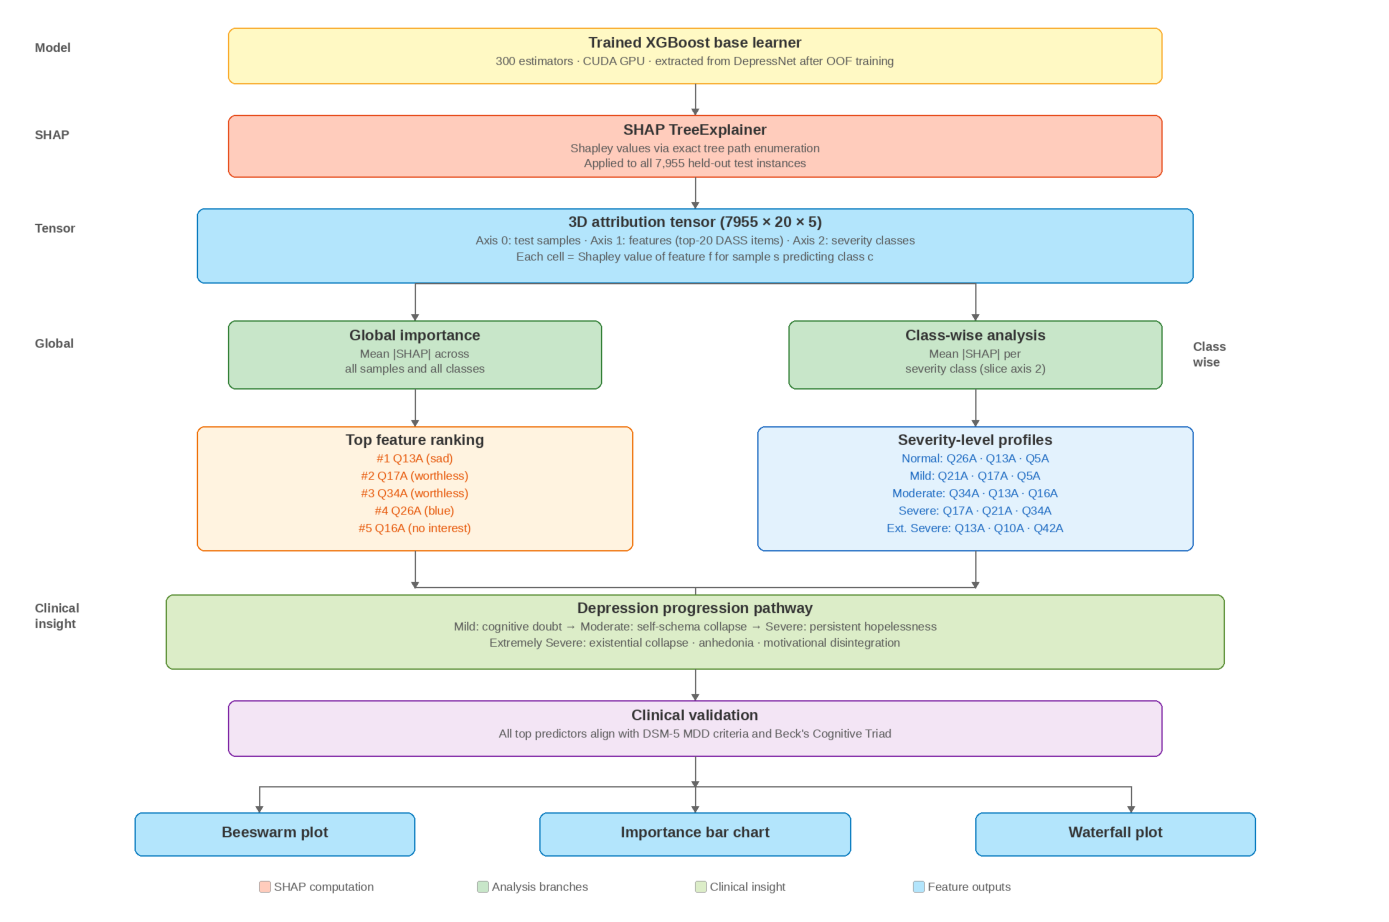

Saved as Figure2_SHAP_Pipeline.png


In [ ]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import os

W, H = 2200, 1450
img = Image.new('RGB', (W, H), '#FFFFFF')
d = ImageDraw.Draw(img)

# Fonts - find available font
font_paths = [
    "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
    "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf",
    "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
]
fp_bold = fp_reg = None
for p in font_paths:
    if os.path.exists(p):
        fp_bold = p
        fp_reg = p.replace("Bold", "Regular")
        if not os.path.exists(fp_reg): fp_reg = fp_bold
        break
if fp_bold is None:
    import subprocess
    print(subprocess.run(['fc-list','--format=%{file}\n'], capture_output=True, text=True).stdout[:3000])
    raise Exception("No font found")

title_font = ImageFont.truetype(fp_bold, 28)
bold_font = ImageFont.truetype(fp_bold, 24)
body_font = ImageFont.truetype(fp_reg, 21)
small_font = ImageFont.truetype(fp_reg, 19)
small_bold = ImageFont.truetype(fp_bold, 19)
label_font = ImageFont.truetype(fp_bold, 20)

def center_text(draw, y, text, font, fill, x_center=None):
    bbox = draw.textbbox((0,0), text, font=font)
    tw = bbox[2] - bbox[0]
    cx = x_center if x_center else W // 2
    draw.text((cx - tw//2, y), text, font=font, fill=fill)

def draw_arrow(draw, x, y1, y2):
    draw.line([(x, y1), (x, y2-8)], fill='#666', width=2)
    draw.polygon([(x-6, y2-10), (x+6, y2-10), (x, y2)], fill='#666')

def side_label(draw, y, text):
    draw.text((40, y), text, font=label_font, fill='#555')

cx = W // 2

# ════ MODEL ════
y = 30
side_label(d, y+20, "Model")
d.rounded_rectangle((350, y, 1850, y+90), radius=12, fill='#FFF9C4', outline='#F9A825', width=2)
center_text(d, y+10, "Trained XGBoost base learner", bold_font, '#333')
center_text(d, y+42, "300 estimators \u00b7 CUDA GPU \u00b7 extracted from DepressNet after OOF training", small_font, '#555')
draw_arrow(d, cx, y+90, y+140)

# ════ SHAP ════
y = 170
side_label(d, y+20, "SHAP")
d.rounded_rectangle((350, y, 1850, y+100), radius=12, fill='#FFCCBC', outline='#E64A19', width=2)
center_text(d, y+10, "SHAP TreeExplainer", bold_font, '#333')
center_text(d, y+42, "Shapley values via exact tree path enumeration", small_font, '#555')
center_text(d, y+66, "Applied to all 7,955 held-out test instances", small_font, '#555')
draw_arrow(d, cx, y+100, y+150)

# ════ TENSOR ════
y = 320
side_label(d, y+20, "Tensor")
d.rounded_rectangle((300, y, 1900, y+120), radius=12, fill='#B3E5FC', outline='#0277BD', width=2)
center_text(d, y+8, "3D attribution tensor (7955 \u00d7 20 \u00d7 5)", bold_font, '#333')
center_text(d, y+40, "Axis 0: test samples \u00b7 Axis 1: features (top-20 DASS items) \u00b7 Axis 2: severity classes", small_font, '#555')
center_text(d, y+66, "Each cell = Shapley value of feature f for sample s predicting class c", small_font, '#555')

y_split = y + 120
draw_arrow(d, 650, y_split, y_split+60)
draw_arrow(d, 1550, y_split, y_split+60)
d.line([(650, y_split), (1550, y_split)], fill='#666', width=2)

# ════ GLOBAL IMPORTANCE ════
y = 500
side_label(d, y+25, "Global")
d.rounded_rectangle((350, y, 950, y+110), radius=12, fill='#C8E6C9', outline='#2E7D32', width=2)
center_text(d, y+10, "Global importance", bold_font, '#333', 650)
center_text(d, y+42, "Mean |SHAP| across", small_font, '#555', 650)
center_text(d, y+66, "all samples and all classes", small_font, '#555', 650)

# ════ CLASS-WISE ════
d.rounded_rectangle((1250, y, 1850, y+110), radius=12, fill='#C8E6C9', outline='#2E7D32', width=2)
center_text(d, y+10, "Class-wise analysis", bold_font, '#333', 1550)
center_text(d, y+42, "Mean |SHAP| per", small_font, '#555', 1550)
center_text(d, y+66, "severity class (slice axis 2)", small_font, '#555', 1550)
d.text((1900, y+30), "Class", font=label_font, fill='#555')
d.text((1900, y+55), "wise", font=label_font, fill='#555')

draw_arrow(d, 650, y+110, y+170)
draw_arrow(d, 1550, y+110, y+170)

# ════ TOP FEATURE RANKING ════
y = 670
d.rounded_rectangle((300, y, 1000, y+200), radius=12, fill='#FFF3E0', outline='#EF6C00', width=2)
center_text(d, y+8, "Top feature ranking", bold_font, '#333', 650)
for i, t in enumerate(["#1 Q13A (sad)","#2 Q17A (worthless)","#3 Q34A (worthless)","#4 Q26A (blue)","#5 Q16A (no interest)"]):
    center_text(d, y+40+i*28, t, small_font, '#E65100', 650)

# ════ SEVERITY PROFILES ════
d.rounded_rectangle((1200, y, 1900, y+200), radius=12, fill='#E3F2FD', outline='#1565C0', width=2)
center_text(d, y+8, "Severity-level profiles", bold_font, '#333', 1550)
for i, t in enumerate(["Normal: Q26A \u00b7 Q13A \u00b7 Q5A","Mild: Q21A \u00b7 Q17A \u00b7 Q5A","Moderate: Q34A \u00b7 Q13A \u00b7 Q16A","Severe: Q17A \u00b7 Q21A \u00b7 Q34A","Ext. Severe: Q13A \u00b7 Q10A \u00b7 Q42A"]):
    center_text(d, y+40+i*28, t, small_font, '#1565C0', 1550)

y_merge = y + 200
draw_arrow(d, 650, y_merge, y_merge+60)
draw_arrow(d, 1550, y_merge, y_merge+60)
d.line([(650, y_merge+58), (1550, y_merge+58)], fill='#666', width=2)
draw_arrow(d, cx, y_merge+58, y_merge+110)

# ════ DEPRESSION PROGRESSION ════
y = 940
side_label(d, y+10, "Clinical")
side_label(d, y+35, "insight")
d.rounded_rectangle((250, y, 1950, y+120), radius=12, fill='#DCEDC8', outline='#558B2F', width=2)
center_text(d, y+8, "Depression progression pathway", bold_font, '#333')
center_text(d, y+40, "Mild: cognitive doubt \u2192 Moderate: self-schema collapse \u2192 Severe: persistent hopelessness", small_font, '#555')
center_text(d, y+66, "Extremely Severe: existential collapse \u00b7 anhedonia \u00b7 motivational disintegration", small_font, '#555')
draw_arrow(d, cx, y+120, y+170)

# ════ CLINICAL VALIDATION ════
y = 1110
d.rounded_rectangle((350, y, 1850, y+90), radius=12, fill='#F3E5F5', outline='#7B1FA2', width=2)
center_text(d, y+10, "Clinical validation", bold_font, '#333')
center_text(d, y+42, "All top predictors align with DSM-5 MDD criteria and Beck's Cognitive Triad", small_font, '#555')
draw_arrow(d, cx, y+90, y+140)

y_out = 1250
d.line([(400, y_out-2), (1800, y_out-2)], fill='#666', width=2)
draw_arrow(d, 400, y_out-2, y_out+40)
draw_arrow(d, cx, y_out-2, y_out+40)
draw_arrow(d, 1800, y_out-2, y_out+40)

# ════ OUTPUTS ════
y = 1290
d.rounded_rectangle((200, y, 650, y+70), radius=12, fill='#B3E5FC', outline='#0277BD', width=2)
center_text(d, y+18, "Beeswarm plot", bold_font, '#333', 425)
d.rounded_rectangle((850, y, 1350, y+70), radius=12, fill='#B3E5FC', outline='#0277BD', width=2)
center_text(d, y+18, "Importance bar chart", bold_font, '#333', cx)
d.rounded_rectangle((1550, y, 2000, y+70), radius=12, fill='#B3E5FC', outline='#0277BD', width=2)
center_text(d, y+18, "Waterfall plot", bold_font, '#333', 1775)

# ════ LEGEND ════
y = 1400
lx = 400
for fill, label in [('#FFCCBC','SHAP computation'),('#C8E6C9','Analysis branches'),('#DCEDC8','Clinical insight'),('#B3E5FC','Feature outputs')]:
    d.rounded_rectangle((lx, y, lx+18, y+18), radius=3, fill=fill, outline='#999', width=1)
    d.text((lx+24, y-2), label, font=small_font, fill='#555')
    lx += 350

img.save('Figure2_SHAP_Pipeline.png', dpi=(300, 300))
plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()
print("Saved as Figure2_SHAP_Pipeline.png")
